# Thailand Street Tracking Dataset  
# Hourly Up/Down People Count Forecasting

## Project goal

This notebook predicts **how many people will move up or down during future hours**, including the **next 3 days**.

This is different from a normal direction classification problem.

| Previous task | New task |
|---|---|
| Predict `direction` for one event | Predict hourly `up_count` and `down_count` |
| Classification | Time-based regression / forecasting |
| One row = one tracking event | One row = one hour |
| Target = `direction` | Targets = `up_count`, `down_count` |

The notebook includes:

1. Dataset loading  
2. Data quality checks  
3. Direction and person filtering  
4. Hourly aggregation  
5. Strong EDA with heatmaps  
6. Leakage discussion  
7. Leakage-safe feature engineering  
8. Time-based train/test split  
9. Baseline models  
10. Machine learning models  
11. TimeSeriesSplit cross-validation  
12. Optional hyperparameter tuning  
13. Model comparison  
14. Actual vs predicted plots  
15. Error analysis  
16. Feature importance  
17. Final model choice  
18. Recursive next-3-days forecasting  
19. Forecast for a specific hour of the day  

---

# 0. Important Methodology Warning

This notebook is built to avoid the main mistake in forecasting: **data leakage**.

When predicting future `up_count` and `down_count`, the model must **not** use current-hour values such as:

- `up_count`
- `down_count`
- `total_count`
- current-hour direction counts
- anything created from the future

The model is only allowed to use:

- time features
- past lag values
- past rolling averages
- past rolling standard deviations

A model can easily get fake scores like **R² = 0.98** if it accidentally uses `total_count`, `up_count`, or `down_count` from the same hour as features. That is not intelligence. That is cheating.

This notebook includes leakage checks before model training.

# 1. Imports and Settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Configuration

Use the full dataset for final results:

```python
DATA_PATH = "thailand_street_tracking_dataset.csv"
```

The notebook can fall back to `traffic_sample_100k.csv` if the full file is not available, but sample-based results should **not** be submitted as final evidence.

In [2]:
DATA_PATH = "../data/thailand_street_tracking_dataset.csv"
SAMPLE_PATH = "../data/sample_dataset.csv"

# Set to True only while testing on a weak laptop.
# For the final notebook/report, use the full file if possible.
FAST_MODE = False

# If FAST_MODE is True, this many raw rows will be sampled after loading.
FAST_SAMPLE_SIZE = 200_000

# People filtering settings.
FILTER_ONLY_PEOPLE = True

# Adjust these if your dataset uses different labels.
PEOPLE_LABELS = [
    "person", "people", "pedestrian", "human", "walker"
]

# Direction standardisation.
# The code looks for "up" and "down" inside the direction text.
# If your labels are different, edit these lists.
UP_KEYWORDS = ["up", "upward", "upwards", "ascending", "north", "northbound", "in", "entry", "enter"]
DOWN_KEYWORDS = ["down", "downward", "downwards", "descending", "south", "southbound", "out", "exit", "leave"]

TARGET_COLS = ["up_count", "down_count"]

# Forecast horizon:
FORECAST_DAYS = 3
FORECAST_HOURS = FORECAST_DAYS * 24

# Optional tuning.
# Keep False at first. Turn True only after the main notebook runs correctly.
RUN_HYPERPARAMETER_TUNING = False

print("Configuration ready.")

Configuration ready.


# 3. Load Dataset

In [3]:
data_file = Path(DATA_PATH)
sample_file = Path(SAMPLE_PATH)

if data_file.exists():
    print(f"Loading full dataset: {DATA_PATH}")
    df = pd.read_csv(data_file)
elif sample_file.exists():
    print(f"Full dataset not found. Loading sample dataset: {SAMPLE_PATH}")
    df = pd.read_csv(sample_file)
else:
    raise FileNotFoundError(
        f"Neither {DATA_PATH} nor {SAMPLE_PATH} was found in this folder. "
        "Put the CSV file in the same folder as this notebook."
    )

if FAST_MODE and len(df) > FAST_SAMPLE_SIZE:
    df = df.sample(n=FAST_SAMPLE_SIZE, random_state=RANDOM_STATE).sort_index().reset_index(drop=True)
    print(f"FAST_MODE enabled. Using {len(df):,} sampled rows.")

print("Dataset loaded.")
print("Shape:", df.shape)
df.head()

Full dataset not found. Loading sample dataset: ../data/sample_dataset.csv
Dataset loaded.
Shape: (100000, 23)


,event_id,timestamp,camera_id,location,city,latitude,longitude,track_id,object_class,direction,crossing_line,detector_model,tracker_model,detection_confidence,tracking_confidence,estimated_speed_kmh,weather_condition,temperature_c,humidity_percent,is_weekend,hour,day_of_week,event_description
0,460b19a8-c2cd-4741-87e6-5bba014ab2fb,2026-04-26 23:15:00,BKK_CAM_02,Silom Road,Bangkok,13.7243,100.5340,930840,person,UP,LINE_A,YOLOv11,ByteTrack,0.85,0.90,1.91,Cloudy,30.0,67,True,23,Sunday,Track ID 930840 crossed UP through LINE_A unde...
1,510a0f3f-6cc3-4f51-938e-388414138095,2026-03-16 18:30:00,CNX_CAM_01,Nimmanhaemin Road,Chiang Mai,18.7961,98.9685,331232,person,DOWN,LINE_C,YOLOv11,ByteTrack,0.76,0.85,1.17,Rainy,28.8,92,False,18,Monday,Track ID 331232 crossed DOWN through LINE_C un...
2,4fc0a83b-8324-48df-96d6-6bfbba25a04a,2026-05-14 11:15:00,BKK_CAM_01,สุขุมวิท ซอย 11,Bangkok,13.7466,100.5550,1183896,person,DOWN,LINE_A,YOLOv11,ByteTrack,0.71,0.97,1.46,Sunny,30.4,62,False,11,Thursday,Track ID 1183896 crossed DOWN through LINE_A u...
3,0cc7ec14-3d66-4717-bdf4-6bcd20e3c39f,2026-04-07 13:45:00,CNX_CAM_01,Nimmanhaemin Road,Chiang Mai,18.7961,98.9685,647074,person,DOWN,LINE_B,YOLOv11,ByteTrack,0.82,0.88,1.92,Sunny,31.2,52,False,13,Tuesday,Track ID 647074 crossed DOWN through LINE_B un...
4,75d7b63a-f293-4e3c-a4f9-012da81a01cd,2026-03-15 16:15:00,HKT_CAM_01,Patong Beach Road,Phuket,7.8963,98.2960,314370,person,DOWN,LINE_A,YOLOv11,ByteTrack,0.78,0.91,1.40,Sunny,33.0,60,True,16,Sunday,Track ID 314370 crossed DOWN through LINE_A un...


# 4. Dataset Overview

In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData info:")
df.info()

Dataset shape: (100000, 23)

Column names:
['event_id', 'timestamp', 'camera_id', 'location', 'city', 'latitude', 'longitude', 'track_id', 'object_class', 'direction', 'crossing_line', 'detector_model', 'tracker_model', 'detection_confidence', 'tracking_confidence', 'estimated_speed_kmh', 'weather_condition', 'temperature_c', 'humidity_percent', 'is_weekend', 'hour', 'day_of_week', 'event_description']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   event_id              100000 non-null  object 
 1   timestamp             100000 non-null  object 
 2   camera_id             100000 non-null  object 
 3   location              100000 non-null  object 
 4   city                  100000 non-null  object 
 5   latitude              100000 non-null  float64
 6   longitude             100000 non-null  float64
 7  

In [5]:
overview_table = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(3),
    "unique_values": df.nunique(dropna=False).values
})

overview_table

,column,dtype,non_null_count,missing_count,missing_percent,unique_values
0,event_id,object,100000,0,0.0,100000
1,timestamp,object,100000,0,0.0,8494
2,camera_id,object,100000,0,0.0,4
3,location,object,100000,0,0.0,4
4,city,object,100000,0,0.0,3
5,latitude,float64,100000,0,0.0,4
6,longitude,float64,100000,0,0.0,4
7,track_id,int64,100000,0,0.0,100000
8,object_class,object,100000,0,0.0,2
9,direction,object,100000,0,0.0,2


## Dataset Overview Explanation

Each original row is one tracking event. For this forecasting project, the original event-level format is not enough. We need to convert it into an **hourly time series**.

The useful raw columns are mainly:

- `timestamp`
- `object_class`
- `direction`
- optionally `camera_id`, `location`, or `city`

The forecasting targets will be created after aggregation:

- `up_count`
- `down_count`

# 5. Data Quality Checks

In [6]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
event_id,0,0.0
tracker_model,0,0.0
day_of_week,0,0.0
hour,0,0.0
is_weekend,0,0.0
humidity_percent,0,0.0
temperature_c,0,0.0
weather_condition,0,0.0
estimated_speed_kmh,0,0.0
tracking_confidence,0,0.0


In [7]:
duplicate_count = df.duplicated().sum()
duplicate_percent = duplicate_count / len(df) * 100

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_percent:.4f}%")

Duplicate rows: 0
Duplicate percentage: 0.0000%


In [8]:
if "event_id" in df.columns:
    event_unique = df["event_id"].nunique()
    print(f"Rows: {len(df):,}")
    print(f"Unique event_id values: {event_unique:,}")
    print(f"Duplicated event_id values: {len(df) - event_unique:,}")
else:
    print("No event_id column found.")

Rows: 100,000
Unique event_id values: 100,000
Duplicated event_id values: 0


In [9]:
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    print("Invalid timestamp values:", df["timestamp"].isna().sum())
    print("Minimum timestamp:", df["timestamp"].min())
    print("Maximum timestamp:", df["timestamp"].max())
else:
    raise KeyError("The dataset must contain a timestamp column.")

Invalid timestamp values: 0
Minimum timestamp: 2026-02-22 00:00:00
Maximum timestamp: 2026-05-22 00:00:00


# 6. Target and Filter Checks

Before forecasting, we must understand two columns:

1. `object_class` — to filter people/pedestrians  
2. `direction` — to identify up/down movement

In [10]:
if "object_class" in df.columns:
    print("Object class distribution:")
    display(df["object_class"].astype(str).str.lower().str.strip().value_counts(dropna=False).head(30))
else:
    raise KeyError("The dataset must contain object_class for people filtering.")

Object class distribution:


object_class
person    71859
car       28141
Name: count, dtype: int64

In [11]:
if "direction" in df.columns:
    print("Direction distribution:")
    display(df["direction"].astype(str).str.lower().str.strip().value_counts(dropna=False).head(30))
else:
    raise KeyError("The dataset must contain direction.")

Direction distribution:


direction
up      51977
down    48023
Name: count, dtype: int64

In [12]:
def standardize_direction(value):
    text = str(value).lower().strip()

    for keyword in UP_KEYWORDS:
        if keyword in text:
            return "up"

    for keyword in DOWN_KEYWORDS:
        if keyword in text:
            return "down"

    return "other"

df["direction_clean"] = df["direction"].apply(standardize_direction)

print("Standardized direction distribution:")
df["direction_clean"].value_counts(dropna=False)

Standardized direction distribution:


direction_clean
up      51977
down    48023
Name: count, dtype: int64

In [13]:
if FILTER_ONLY_PEOPLE:
    object_clean = df["object_class"].astype(str).str.lower().str.strip()
    people_mask = object_clean.isin(PEOPLE_LABELS)

    if people_mask.sum() == 0:
        print("WARNING: No rows matched PEOPLE_LABELS.")
        print("Available object_class values:")
        display(object_clean.value_counts().head(50))
        raise ValueError(
            "No people rows found. Edit PEOPLE_LABELS to match your dataset's object_class labels."
        )

    people_df = df.loc[people_mask].copy()
    print(f"People rows selected: {len(people_df):,} out of {len(df):,}")
else:
    people_df = df.copy()
    print("FILTER_ONLY_PEOPLE is False. Using all object classes.")

People rows selected: 71,859 out of 100,000


In [14]:
people_df = people_df[people_df["direction_clean"].isin(["up", "down"])].copy()

print("Rows after keeping only up/down directions:", len(people_df))
print("\nUp/down distribution:")
people_df["direction_clean"].value_counts()

Rows after keeping only up/down directions: 71859

Up/down distribution:


direction_clean
up      37315
down    34544
Name: count, dtype: int64

## Important

If the number of rows above is too small, your direction mapping is probably wrong.  
Check the original `direction` values and update:

```python
UP_KEYWORDS
DOWN_KEYWORDS
```

Do not continue modeling until `up` and `down` are correctly detected.

# 7. Create Hourly Up/Down Count Dataset

The model should not predict on the raw event-level table.  
It must predict on an aggregated hourly table.

One row will represent:

```text
one hour = up_count + down_count
```

In [15]:
people_df["time_hour"] = people_df["timestamp"].dt.floor("H")

hourly_long = (
    people_df
    .groupby(["time_hour", "direction_clean"])
    .size()
    .reset_index(name="count")
)

hourly_long.head()

,time_hour,direction_clean,count
0,2026-02-22 00:00:00,down,2
1,2026-02-22 00:00:00,up,5
2,2026-02-22 01:00:00,down,6
3,2026-02-22 01:00:00,up,2
4,2026-02-22 02:00:00,down,3


In [16]:
hourly = (
    hourly_long
    .pivot_table(
        index="time_hour",
        columns="direction_clean",
        values="count",
        fill_value=0
    )
    .reset_index()
)

# Make sure both required target columns exist.
if "up" not in hourly.columns:
    hourly["up"] = 0
if "down" not in hourly.columns:
    hourly["down"] = 0

hourly = hourly.rename(columns={
    "up": "up_count",
    "down": "down_count"
})

hourly = hourly[["time_hour", "up_count", "down_count"]].copy()
hourly["total_count"] = hourly["up_count"] + hourly["down_count"]

# Reindex to continuous hourly timeline.
full_hour_index = pd.date_range(
    start=hourly["time_hour"].min(),
    end=hourly["time_hour"].max(),
    freq="H"
)

hourly = (
    hourly
    .set_index("time_hour")
    .reindex(full_hour_index)
    .rename_axis("time_hour")
    .reset_index()
)

hourly[["up_count", "down_count", "total_count"]] = hourly[["up_count", "down_count", "total_count"]].fillna(0)

# Convert counts to integers.
for col in ["up_count", "down_count", "total_count"]:
    hourly[col] = hourly[col].astype(int)

print("Hourly dataset shape:", hourly.shape)
hourly.head()

Hourly dataset shape: (2137, 4)


direction_clean,time_hour,up_count,down_count,total_count
0,2026-02-22 00:00:00,5,2,7
1,2026-02-22 01:00:00,2,6,8
2,2026-02-22 02:00:00,2,3,5
3,2026-02-22 03:00:00,7,6,13
4,2026-02-22 04:00:00,6,6,12


In [17]:
print("Hourly dataset time range")
print("Start:", hourly["time_hour"].min())
print("End:", hourly["time_hour"].max())
print("Number of hourly rows:", len(hourly))

hourly[["up_count", "down_count", "total_count"]].describe().T

Hourly dataset time range
Start: 2026-02-22 00:00:00
End: 2026-05-22 00:00:00
Number of hourly rows: 2137


,count,mean,std,min,25%,50%,75%,max
direction_clean,,,,,,,,
up_count,2137.0,17.461394,11.317744,0.0,8.0,14.0,25.0,57.0
down_count,2137.0,16.164717,10.314575,0.0,8.0,14.0,24.0,48.0
total_count,2137.0,33.626111,20.823679,0.0,16.0,28.0,50.0,93.0


# 8. EDA: Movement Distribution

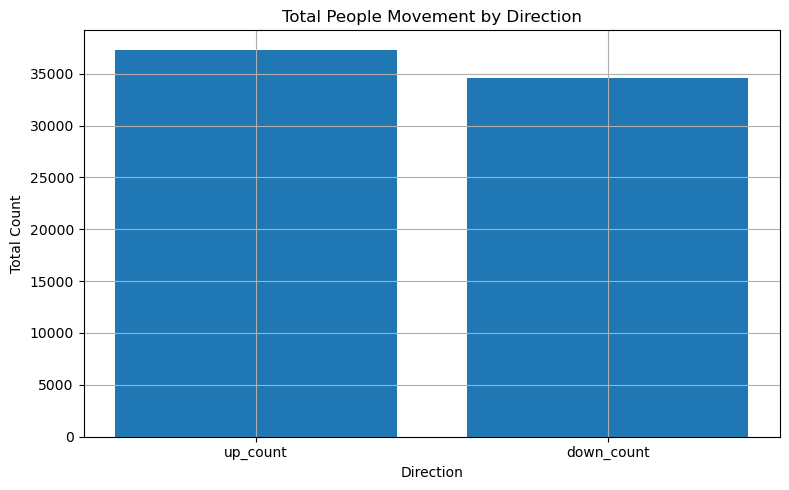

direction_clean
up_count      37315
down_count    34544
dtype: int64

In [18]:
direction_totals = hourly[["up_count", "down_count"]].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(direction_totals.index, direction_totals.values)
plt.title("Total People Movement by Direction")
plt.xlabel("Direction")
plt.ylabel("Total Count")
plt.tight_layout()
plt.show()

direction_totals

In [19]:
hourly["up_share"] = np.where(hourly["total_count"] > 0, hourly["up_count"] / hourly["total_count"], np.nan)
hourly["down_share"] = np.where(hourly["total_count"] > 0, hourly["down_count"] / hourly["total_count"], np.nan)

share_summary = hourly[["up_share", "down_share"]].describe().T
share_summary

,count,mean,std,min,25%,50%,75%,max
direction_clean,,,,,,,,
up_share,2136.0,0.517734,0.10896,0.0,0.454545,0.517241,0.580645,1.0
down_share,2136.0,0.482266,0.10896,0.0,0.419355,0.482759,0.545455,1.0


# 9. EDA: Hourly Patterns

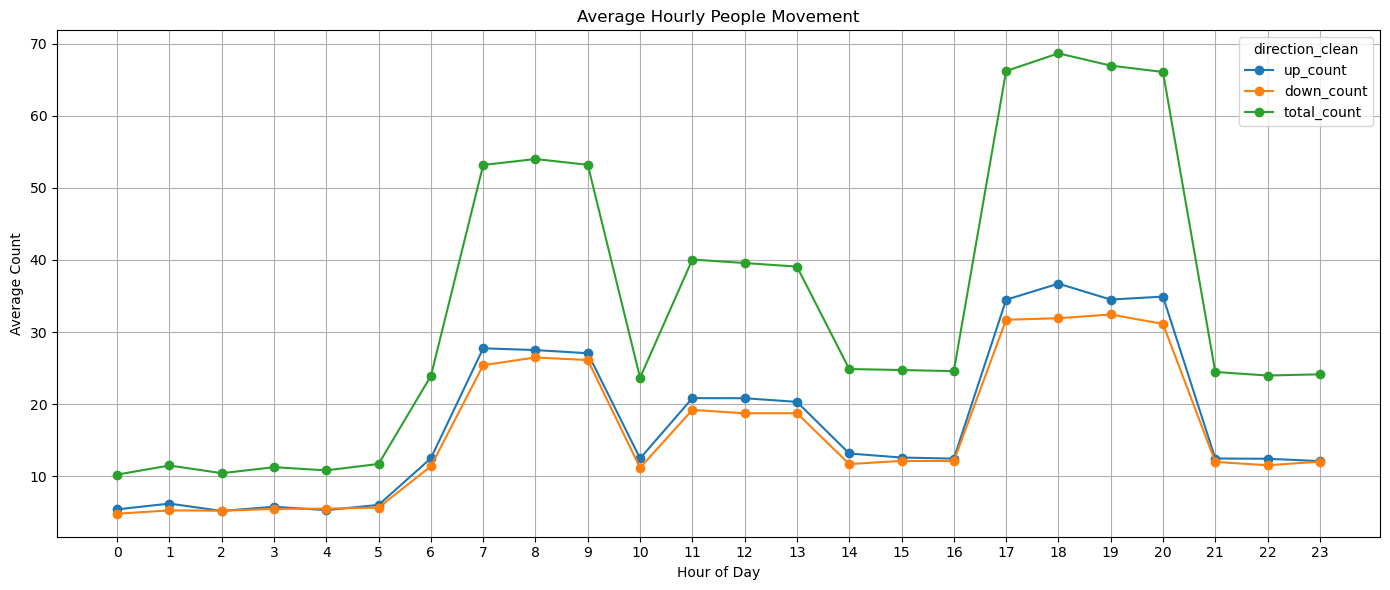

direction_clean,up_count,down_count,total_count
hour,,,
0,5.422222,4.822222,10.244444
1,6.224719,5.280899,11.505618
2,5.202247,5.235955,10.438202
3,5.786517,5.483146,11.269663
4,5.314607,5.516854,10.831461
5,6.044944,5.674157,11.719101
6,12.516854,11.404494,23.921348
7,27.752809,25.415730,53.168539
8,27.505618,26.483146,53.988764


In [20]:
hourly["hour"] = hourly["time_hour"].dt.hour
hourly["day_of_week_num"] = hourly["time_hour"].dt.dayofweek
hourly["day_name"] = hourly["time_hour"].dt.day_name()
hourly["date"] = hourly["time_hour"].dt.date
hourly["is_weekend"] = hourly["day_of_week_num"].isin([5, 6]).astype(int)

hourly_by_hour = hourly.groupby("hour")[["up_count", "down_count", "total_count"]].mean()

hourly_by_hour.plot(kind="line", marker="o", figsize=(14, 6))
plt.title("Average Hourly People Movement")
plt.xlabel("Hour of Day")
plt.ylabel("Average Count")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

hourly_by_hour

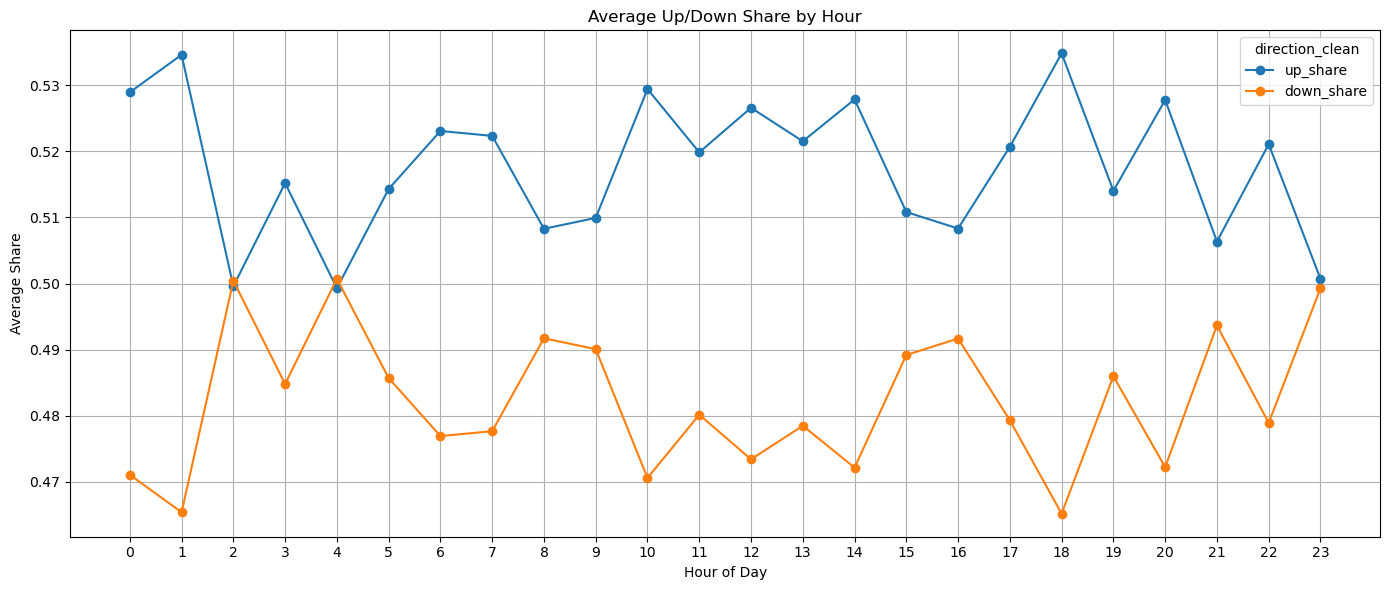

direction_clean,up_share,down_share
hour,,
0,0.528927,0.471073
1,0.534603,0.465397
2,0.499583,0.500417
3,0.515191,0.484809
4,0.499290,0.500710
5,0.514298,0.485702
6,0.523074,0.476926
7,0.522335,0.477665
8,0.508280,0.491720


In [21]:
share_by_hour = hourly.groupby("hour")[["up_share", "down_share"]].mean()

share_by_hour.plot(kind="line", marker="o", figsize=(14, 6))
plt.title("Average Up/Down Share by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Share")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

share_by_hour

# 10. EDA: Daily and Weekly Patterns

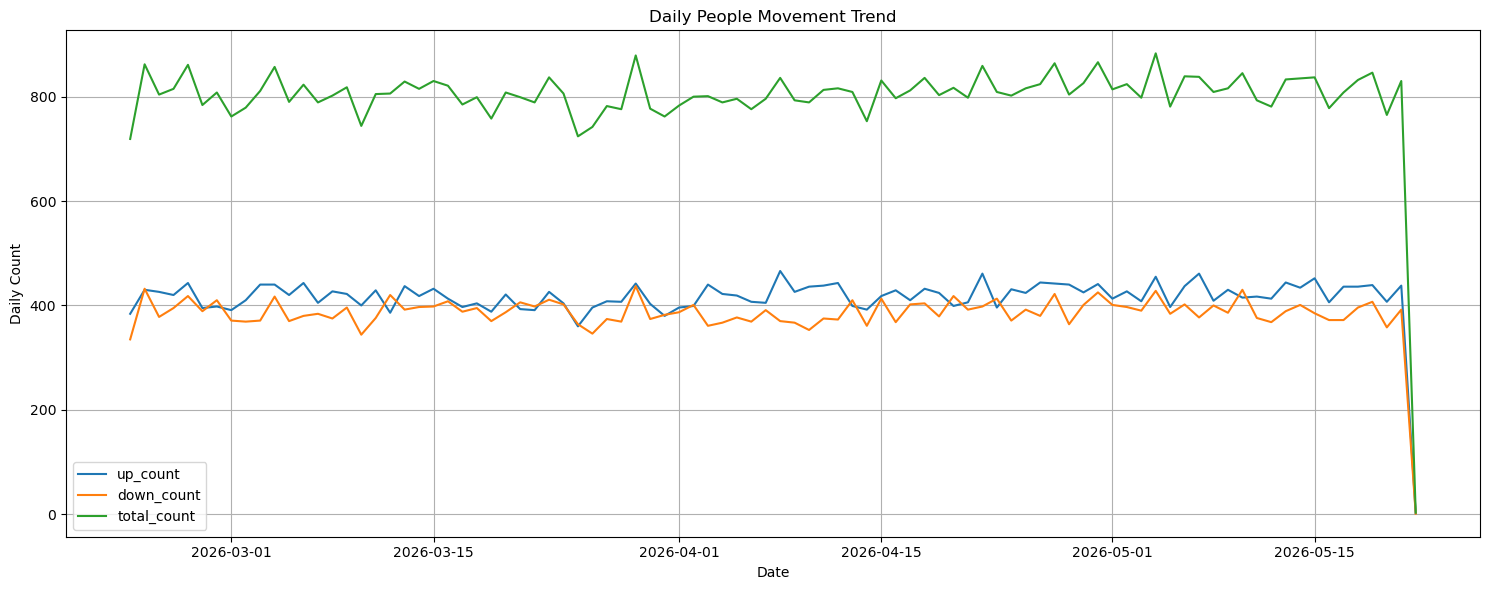

direction_clean,date,up_count,down_count,total_count
0,2026-02-22,384,335,719
1,2026-02-23,430,432,862
2,2026-02-24,426,378,804
3,2026-02-25,420,395,815
4,2026-02-26,443,418,861


In [22]:
daily_counts = hourly.groupby("date")[["up_count", "down_count", "total_count"]].sum().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(daily_counts["date"], daily_counts["up_count"], label="up_count")
plt.plot(daily_counts["date"], daily_counts["down_count"], label="down_count")
plt.plot(daily_counts["date"], daily_counts["total_count"], label="total_count")
plt.title("Daily People Movement Trend")
plt.xlabel("Date")
plt.ylabel("Daily Count")
plt.legend()
plt.tight_layout()
plt.show()

daily_counts.head()

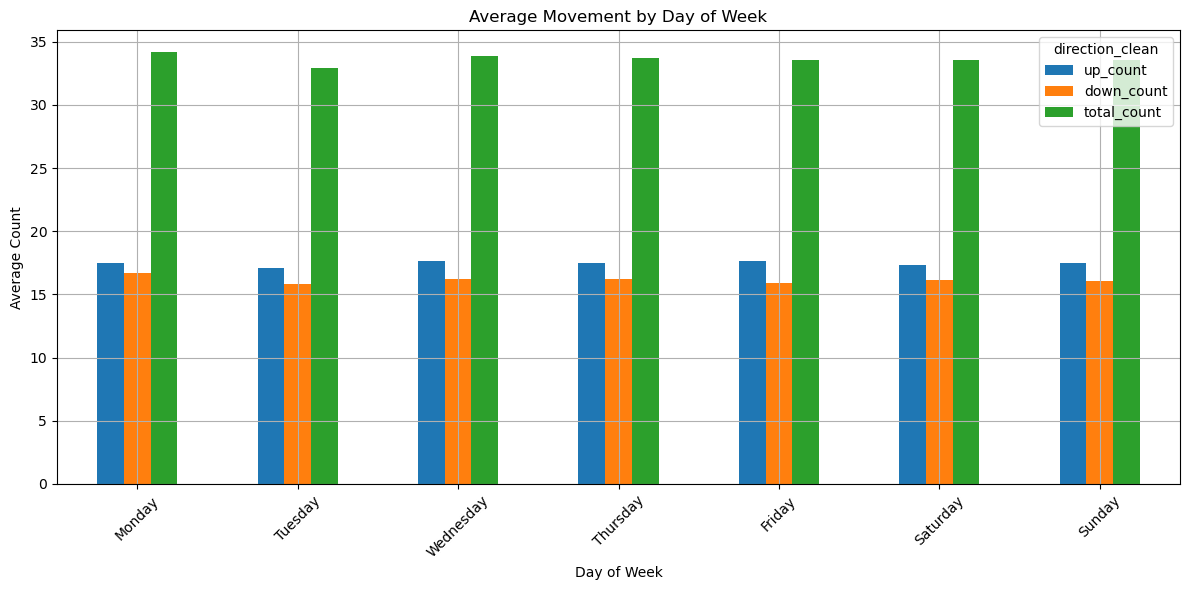

direction_clean,up_count,down_count,total_count
day_name,,,
Monday,17.496795,16.695513,34.192308
Tuesday,17.112179,15.807692,32.919872
Wednesday,17.650641,16.233974,33.884615
Thursday,17.490385,16.243590,33.733974
Friday,17.636678,15.903114,33.539792
Saturday,17.361111,16.177083,33.538194
Sunday,17.487179,16.073718,33.560897


In [23]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekly_pattern = (
    hourly
    .groupby("day_name")[["up_count", "down_count", "total_count"]]
    .mean()
    .reindex(day_order)
)

weekly_pattern.plot(kind="bar", figsize=(12, 6))
plt.title("Average Movement by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

weekly_pattern

# 11. EDA: Heatmaps

These heatmaps are very important because the task is time-based.  
They show whether movement changes by **hour** and **day of week**.

In [24]:
def plot_heatmap(matrix, title, xlabel="Hour of Day", ylabel="Day of Week"):
    plt.figure(figsize=(15, 6))
    plt.imshow(matrix.values, aspect="auto")
    plt.colorbar(label="Average Count")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(ticks=np.arange(len(matrix.columns)), labels=matrix.columns)
    plt.yticks(ticks=np.arange(len(matrix.index)), labels=matrix.index)

    # Add text labels only when the matrix is not too large.
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iloc[i, j]
            plt.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

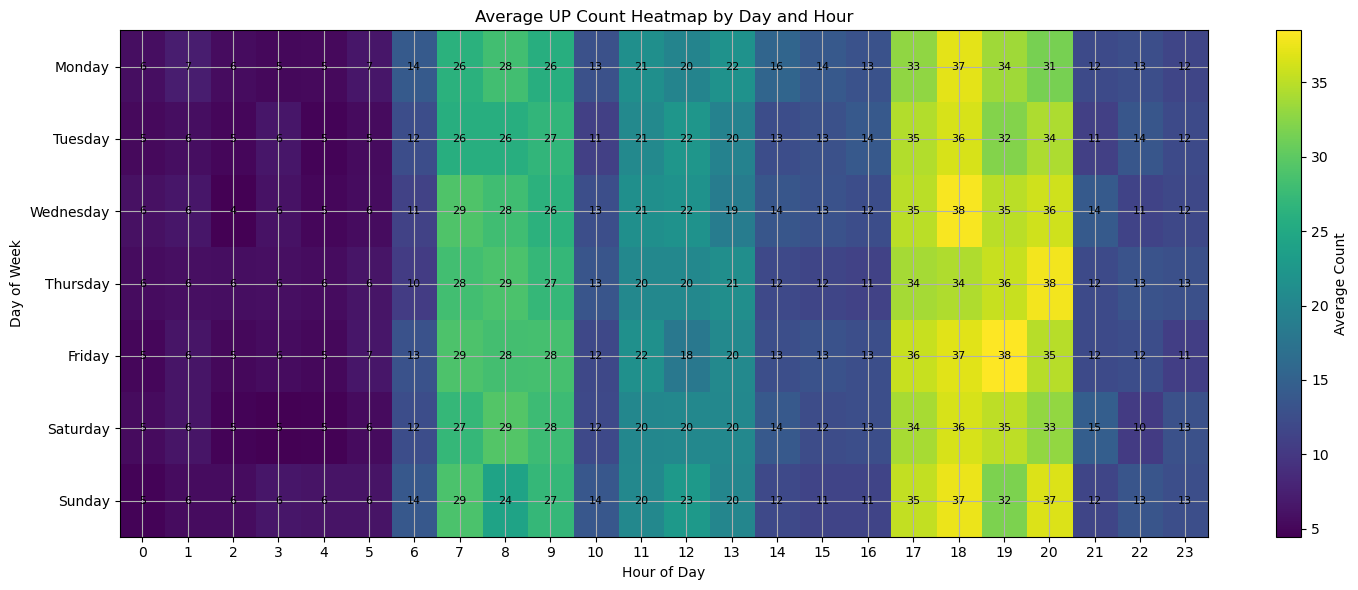

In [25]:
up_heatmap = (
    hourly
    .pivot_table(index="day_name", columns="hour", values="up_count", aggfunc="mean")
    .reindex(day_order)
)

plot_heatmap(up_heatmap, "Average UP Count Heatmap by Day and Hour")

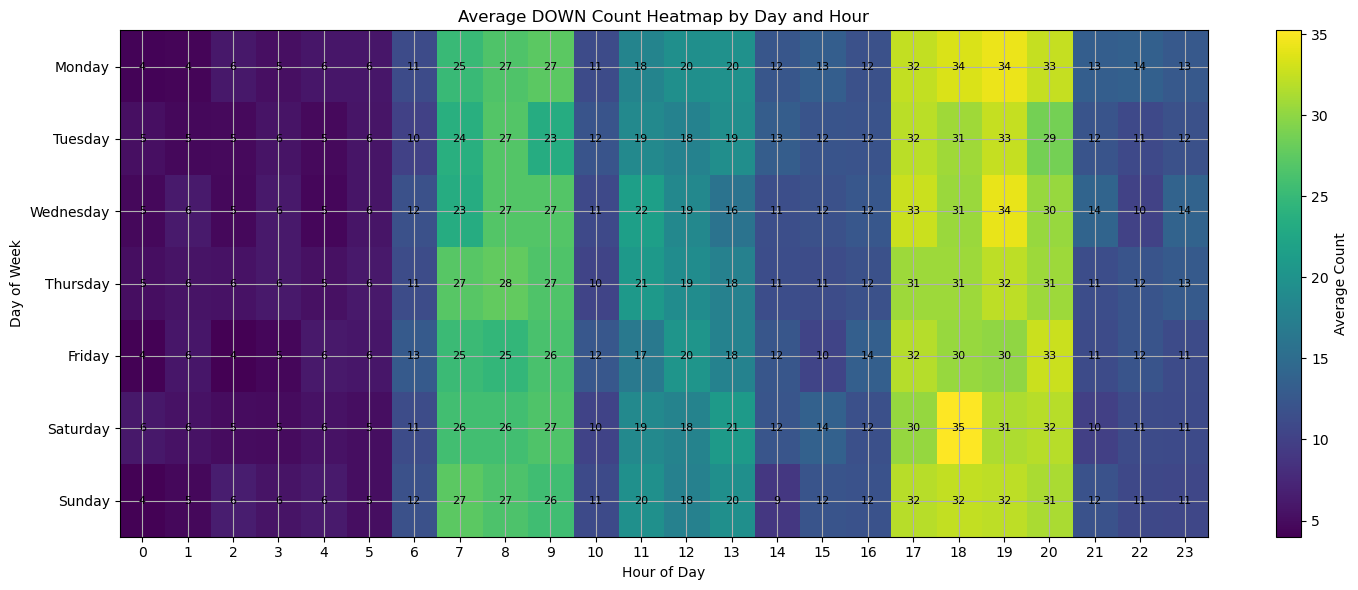

In [26]:
down_heatmap = (
    hourly
    .pivot_table(index="day_name", columns="hour", values="down_count", aggfunc="mean")
    .reindex(day_order)
)

plot_heatmap(down_heatmap, "Average DOWN Count Heatmap by Day and Hour")

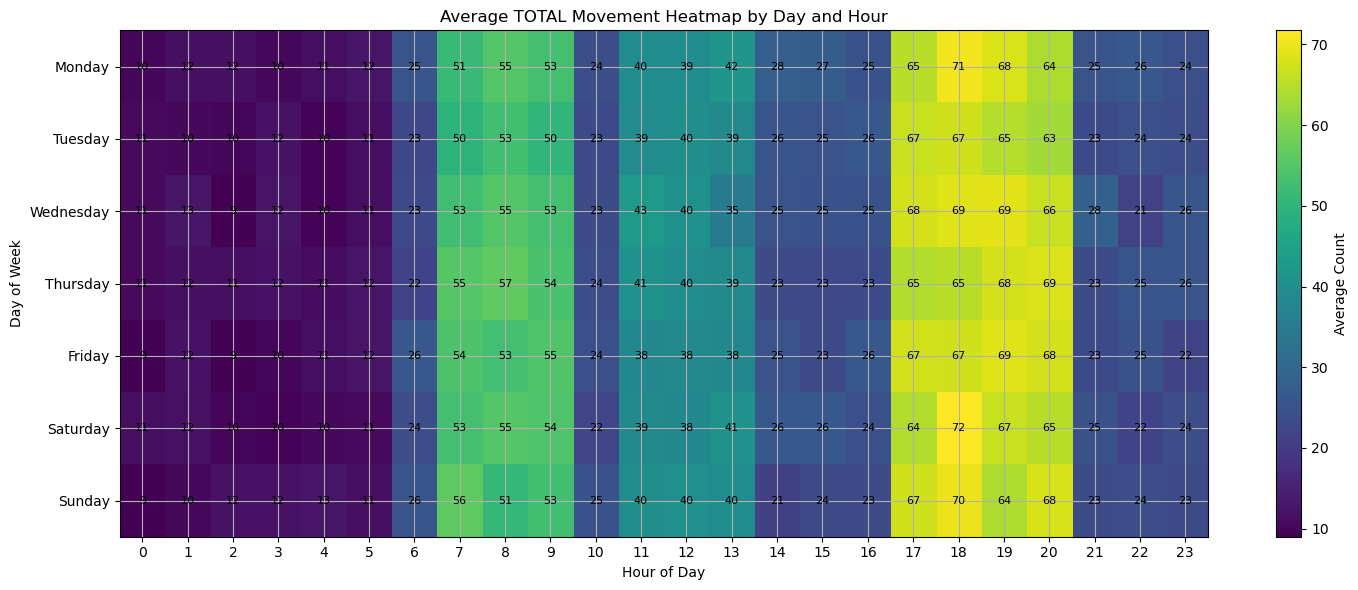

In [27]:
total_heatmap = (
    hourly
    .pivot_table(index="day_name", columns="hour", values="total_count", aggfunc="mean")
    .reindex(day_order)
)

plot_heatmap(total_heatmap, "Average TOTAL Movement Heatmap by Day and Hour")

# 12. EDA: Correlation Heatmap

High correlation between `up_count`, `down_count`, and `total_count` is expected because:

```text
total_count = up_count + down_count
```

This heatmap is for analysis only.  
The model must not use current-hour target columns as input features.

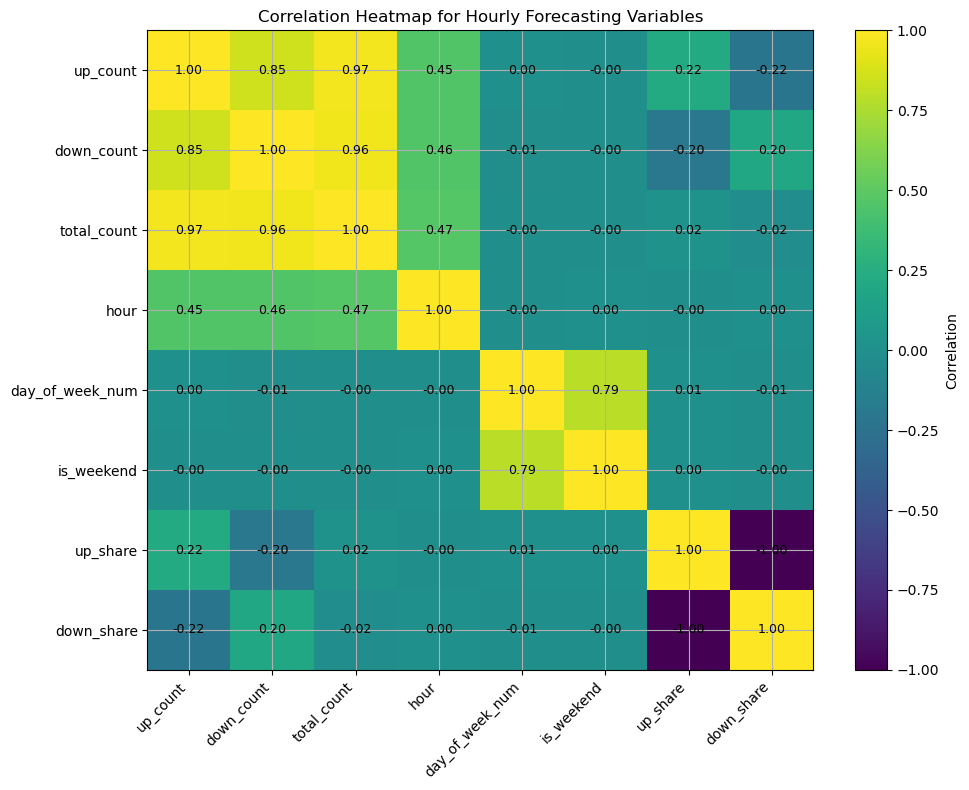

direction_clean,up_count,down_count,total_count,hour,day_of_week_num,is_weekend,up_share,down_share
direction_clean,,,,,,,,
up_count,1.000000,0.852954,0.965997,0.454765,0.002941,-0.001918,0.224976,-0.224976
down_count,0.852954,1.000000,0.958913,0.455842,-0.010155,-0.002507,-0.200524,0.200524
total_count,0.965997,0.958913,1.000000,0.472958,-0.003432,-0.002284,0.022953,-0.022953
hour,0.454765,0.455842,0.472958,1.000000,-0.000400,0.000486,-0.004737,0.004737
day_of_week_num,0.002941,-0.010155,-0.003432,-0.000400,1.000000,0.794532,0.007511,-0.007511
is_weekend,-0.001918,-0.002507,-0.002284,0.000486,0.794532,1.000000,0.000998,-0.000998
up_share,0.224976,-0.200524,0.022953,-0.004737,0.007511,0.000998,1.000000,-1.000000
down_share,-0.224976,0.200524,-0.022953,0.004737,-0.007511,-0.000998,-1.000000,1.000000


In [28]:
corr_cols = ["up_count", "down_count", "total_count", "hour", "day_of_week_num", "is_weekend", "up_share", "down_share"]
corr_cols = [col for col in corr_cols if col in hourly.columns]

corr_matrix = hourly[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix.values, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Correlation Heatmap for Hourly Forecasting Variables")
plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(corr_matrix.index)), labels=corr_matrix.index)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

corr_matrix

## Correlation Interpretation

The heatmap may show very high correlations between:

- `up_count`
- `down_count`
- `total_count`

This does **not** mean the model should use all of them as features.

For example, if the target is `up_count`, using `total_count` from the same hour is leakage because:

```text
total_count = up_count + down_count
```

That would allow the model to indirectly see the answer.

The correct approach is to use only **past values**, such as:

- `up_count_lag_24`
- `down_count_lag_24`
- `up_count_roll_mean_24`
- `down_count_roll_mean_24`

These are allowed because they come from the past.

# 13. Leakage-Safe Feature Engineering

This is the most important modeling section.

The target columns are:

```python
up_count
down_count
```

The model will not use these current-hour values as features.

Instead, it will use:

- calendar features
- cyclical time features
- lag features
- rolling statistics shifted by one hour
- expanding historical means shifted by one hour

In [29]:
def make_time_features(data):
    out = data.copy()

    out["hour"] = out["time_hour"].dt.hour
    out["day_of_week_num"] = out["time_hour"].dt.dayofweek
    out["day_of_month"] = out["time_hour"].dt.day
    out["month"] = out["time_hour"].dt.month
    out["is_weekend"] = out["day_of_week_num"].isin([5, 6]).astype(int)

    # Cyclical features.
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)

    out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week_num"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week_num"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)

    return out


def make_lag_rolling_features(data, target_cols=TARGET_COLS):
    out = make_time_features(data)

    # Trimmed feature set to reduce variance and overfitting.
    # Keep informative lags; keep rolling mean (level/trend) and a rolling std
    # (recent volatility). Dropped rolling min/max and several redundant windows,
    # which produced many near-duplicate noisy columns the trees could memorize.
    lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
    mean_windows = [6, 24, 168]
    std_windows = [24, 168]

    for target in target_cols:
        for lag in lags:
            out[f"{target}_lag_{lag}"] = out[target].shift(lag)

        shifted = out[target].shift(1)

        for window in mean_windows:
            out[f"{target}_roll_mean_{window}"] = shifted.rolling(
                window=window, min_periods=max(2, window // 4)
            ).mean()

        for window in std_windows:
            out[f"{target}_roll_std_{window}"] = shifted.rolling(
                window=window, min_periods=max(2, window // 4)
            ).std()

        out[f"{target}_expanding_mean"] = shifted.expanding(min_periods=24).mean()

    # Allowed total-based features because they are lagged, not same-hour.
    out["total_lag_1"] = out["up_count_lag_1"] + out["down_count_lag_1"]
    out["total_lag_24"] = out["up_count_lag_24"] + out["down_count_lag_24"]
    out["total_lag_168"] = out["up_count_lag_168"] + out["down_count_lag_168"]

    return out


model_df_raw = hourly[["time_hour", "up_count", "down_count"]].copy()
model_df = make_lag_rolling_features(model_df_raw)

print("Shape before dropping lag NaNs:", model_df.shape)

model_df = model_df.dropna().reset_index(drop=True)

print("Shape after dropping lag NaNs:", model_df.shape)
model_df.head()

Shape before dropping lag NaNs: (2137, 47)
Shape after dropping lag NaNs: (1969, 47)


direction_clean,time_hour,up_count,down_count,hour,day_of_week_num,day_of_month,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,up_count_lag_1,up_count_lag_2,up_count_lag_3,up_count_lag_6,up_count_lag_12,up_count_lag_24,up_count_lag_48,up_count_lag_72,up_count_lag_168,up_count_roll_mean_6,up_count_roll_mean_24,up_count_roll_mean_168,up_count_roll_std_24,up_count_roll_std_168,up_count_expanding_mean,down_count_lag_1,down_count_lag_2,down_count_lag_3,down_count_lag_6,down_count_lag_12,down_count_lag_24,down_count_lag_48,down_count_lag_72,down_count_lag_168,down_count_roll_mean_6,down_count_roll_mean_24,down_count_roll_mean_168,down_count_roll_std_24,down_count_roll_std_168,down_count_expanding_mean,total_lag_1,total_lag_24,total_lag_168
0,2026-03-01 00:00:00,7,3,0,6,1,3,1,0.000000,1.000000,-0.781831,0.62349,1.0,6.123234e-17,14.0,13.0,19.0,34.0,15.0,3.0,6.0,8.0,5.0,24.166667,16.583333,17.238095,9.454314,11.577512,17.238095,9.0,18.0,9.0,26.0,17.0,6.0,5.0,7.0,2.0,23.166667,17.083333,16.410714,10.993740,10.873431,16.410714,23.0,9.0,7.0
1,2026-03-01 01:00:00,2,4,1,6,1,3,1,0.258819,0.965926,-0.781831,0.62349,1.0,6.123234e-17,7.0,14.0,13.0,37.0,17.0,10.0,7.0,8.0,2.0,19.666667,16.750000,17.250000,9.237212,11.565875,17.177515,3.0,9.0,18.0,37.0,18.0,8.0,1.0,5.0,6.0,19.333333,16.958333,16.416667,11.141303,10.865766,16.331361,10.0,18.0,8.0
2,2026-03-01 02:00:00,3,9,2,6,1,3,1,0.500000,0.866025,-0.781831,0.62349,1.0,6.123234e-17,2.0,7.0,14.0,28.0,15.0,6.0,6.0,6.0,2.0,13.833333,16.416667,17.250000,9.627482,11.565875,17.088235,4.0,3.0,9.0,40.0,16.0,6.0,2.0,3.0,3.0,13.833333,16.791667,16.404762,11.309785,10.878335,16.258824,6.0,12.0,5.0
3,2026-03-01 03:00:00,12,4,3,6,1,3,1,0.707107,0.707107,-0.781831,0.62349,1.0,6.123234e-17,3.0,2.0,7.0,19.0,14.0,5.0,7.0,7.0,7.0,9.666667,16.291667,17.255952,9.786766,11.558234,17.005848,9.0,4.0,3.0,9.0,15.0,1.0,5.0,10.0,6.0,8.666667,16.916667,16.440476,11.201384,10.843858,16.216374,12.0,6.0,13.0
4,2026-03-01 04:00:00,6,8,4,6,1,3,1,0.866025,0.500000,-0.781831,0.62349,1.0,6.123234e-17,12.0,3.0,2.0,13.0,14.0,1.0,5.0,6.0,6.0,8.500000,16.583333,17.285714,9.536733,11.538087,16.976744,4.0,9.0,4.0,18.0,14.0,4.0,7.0,4.0,6.0,7.833333,17.041667,16.428571,11.031493,10.856479,16.145349,16.0,5.0,12.0


# 14. Feature List and Leakage Audit

In [30]:
forbidden_features = [
    "up_count",
    "down_count",
    "total_count",
    "count",
    "direction",
    "direction_clean",
    "up_share",
    "down_share",
    "time_hour",
    "date"
]

feature_cols = [
    col for col in model_df.columns
    if col not in forbidden_features
]

print("Number of features:", len(feature_cols))
print("\nFeature columns:")
print(feature_cols)

leakage_found = [col for col in forbidden_features if col in feature_cols]

if leakage_found:
    raise ValueError(f"LEAKAGE DETECTED. These forbidden columns are in X: {leakage_found}")
else:
    print("Leakage audit passed. No forbidden same-hour target columns are used as features.")

Number of features: 44

Feature columns:
['hour', 'day_of_week_num', 'day_of_month', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'up_count_lag_1', 'up_count_lag_2', 'up_count_lag_3', 'up_count_lag_6', 'up_count_lag_12', 'up_count_lag_24', 'up_count_lag_48', 'up_count_lag_72', 'up_count_lag_168', 'up_count_roll_mean_6', 'up_count_roll_mean_24', 'up_count_roll_mean_168', 'up_count_roll_std_24', 'up_count_roll_std_168', 'up_count_expanding_mean', 'down_count_lag_1', 'down_count_lag_2', 'down_count_lag_3', 'down_count_lag_6', 'down_count_lag_12', 'down_count_lag_24', 'down_count_lag_48', 'down_count_lag_72', 'down_count_lag_168', 'down_count_roll_mean_6', 'down_count_roll_mean_24', 'down_count_roll_mean_168', 'down_count_roll_std_24', 'down_count_roll_std_168', 'down_count_expanding_mean', 'total_lag_1', 'total_lag_24', 'total_lag_168']
Leakage audit passed. No forbidden same-hour target columns are used as features.


In [31]:
X = model_df[feature_cols].copy()
y = model_df[TARGET_COLS].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (1969, 44)
y shape: (1969, 2)


direction_clean,hour,day_of_week_num,day_of_month,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,up_count_lag_1,up_count_lag_2,up_count_lag_3,up_count_lag_6,up_count_lag_12,up_count_lag_24,up_count_lag_48,up_count_lag_72,up_count_lag_168,up_count_roll_mean_6,up_count_roll_mean_24,up_count_roll_mean_168,up_count_roll_std_24,up_count_roll_std_168,up_count_expanding_mean,down_count_lag_1,down_count_lag_2,down_count_lag_3,down_count_lag_6,down_count_lag_12,down_count_lag_24,down_count_lag_48,down_count_lag_72,down_count_lag_168,down_count_roll_mean_6,down_count_roll_mean_24,down_count_roll_mean_168,down_count_roll_std_24,down_count_roll_std_168,down_count_expanding_mean,total_lag_1,total_lag_24,total_lag_168
0,0,6,1,3,1,0.000000,1.000000,-0.781831,0.62349,1.0,6.123234e-17,14.0,13.0,19.0,34.0,15.0,3.0,6.0,8.0,5.0,24.166667,16.583333,17.238095,9.454314,11.577512,17.238095,9.0,18.0,9.0,26.0,17.0,6.0,5.0,7.0,2.0,23.166667,17.083333,16.410714,10.993740,10.873431,16.410714,23.0,9.0,7.0
1,1,6,1,3,1,0.258819,0.965926,-0.781831,0.62349,1.0,6.123234e-17,7.0,14.0,13.0,37.0,17.0,10.0,7.0,8.0,2.0,19.666667,16.750000,17.250000,9.237212,11.565875,17.177515,3.0,9.0,18.0,37.0,18.0,8.0,1.0,5.0,6.0,19.333333,16.958333,16.416667,11.141303,10.865766,16.331361,10.0,18.0,8.0
2,2,6,1,3,1,0.500000,0.866025,-0.781831,0.62349,1.0,6.123234e-17,2.0,7.0,14.0,28.0,15.0,6.0,6.0,6.0,2.0,13.833333,16.416667,17.250000,9.627482,11.565875,17.088235,4.0,3.0,9.0,40.0,16.0,6.0,2.0,3.0,3.0,13.833333,16.791667,16.404762,11.309785,10.878335,16.258824,6.0,12.0,5.0
3,3,6,1,3,1,0.707107,0.707107,-0.781831,0.62349,1.0,6.123234e-17,3.0,2.0,7.0,19.0,14.0,5.0,7.0,7.0,7.0,9.666667,16.291667,17.255952,9.786766,11.558234,17.005848,9.0,4.0,3.0,9.0,15.0,1.0,5.0,10.0,6.0,8.666667,16.916667,16.440476,11.201384,10.843858,16.216374,12.0,6.0,13.0
4,4,6,1,3,1,0.866025,0.500000,-0.781831,0.62349,1.0,6.123234e-17,12.0,3.0,2.0,13.0,14.0,1.0,5.0,6.0,6.0,8.500000,16.583333,17.285714,9.536733,11.538087,16.976744,4.0,9.0,4.0,18.0,14.0,4.0,7.0,4.0,6.0,7.833333,17.041667,16.428571,11.031493,10.856479,16.145349,16.0,5.0,12.0


direction_clean,up_count,down_count
0,7,3
1,2,4
2,3,9
3,12,4
4,6,8


# 15. Time-Based Train/Test Split

For forecasting, random splitting is dangerous.

Bad:

```python
train_test_split(..., shuffle=True)
```

Good:

```text
first 80% of time = training
last 20% of time = testing
```

This simulates the real situation where we train on the past and predict the future.

In [32]:
split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COLS]

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COLS]

print("Train period:")
print(train_df["time_hour"].min(), "to", train_df["time_hour"].max())

print("\nTest period:")
print(test_df["time_hour"].min(), "to", test_df["time_hour"].max())

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train period:
2026-03-01 00:00:00 to 2026-05-05 14:00:00

Test period:
2026-05-05 15:00:00 to 2026-05-22 00:00:00

Train shape: (1575, 44) (1575, 2)
Test shape: (394, 44) (394, 2)


# 16. Evaluation Functions

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def rmse(y_true, y_pred):
    # Version-safe RMSE calculation
    return np.sqrt(mean_squared_error(y_true, y_pred))


def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    result = np.where(
        denominator == 0,
        0,
        np.abs(y_true - y_pred) / denominator
    )
    
    return np.mean(result) * 100


def evaluate_predictions(y_true_df, y_pred_array, model_name):
    y_pred_df = pd.DataFrame(
        y_pred_array,
        columns=TARGET_COLS,
        index=y_true_df.index
    )
    
    rows = []
    
    for target in TARGET_COLS:
        rows.append({
            "model": model_name,
            "target": target,
            "MAE": mean_absolute_error(y_true_df[target], y_pred_df[target]),
            "RMSE": rmse(y_true_df[target], y_pred_df[target]),
            "R2": r2_score(y_true_df[target], y_pred_df[target]),
            "sMAPE_%": smape(y_true_df[target], y_pred_df[target])
        })
    
    rows.append({
        "model": model_name,
        "target": "average",
        "MAE": np.mean([row["MAE"] for row in rows]),
        "RMSE": np.mean([row["RMSE"] for row in rows]),
        "R2": np.mean([row["R2"] for row in rows]),
        "sMAPE_%": np.mean([row["sMAPE_%"] for row in rows])
    })
    
    return pd.DataFrame(rows)


def clip_count_predictions(pred):
    pred = np.asarray(pred)
    pred = np.where(pred < 0, 0, pred)
    return pred

# 17. Baseline Models

Before trusting machine learning, compare it against simple baselines.

If a simple baseline beats the ML model, the ML model is not good enough.

In [34]:
baseline_results = []

# Baseline 1: previous hour
baseline_prev_hour = test_df[["up_count_lag_1", "down_count_lag_1"]].values
baseline_results.append(evaluate_predictions(y_test, baseline_prev_hour, "Baseline: Previous Hour"))

# Baseline 2: same hour yesterday
baseline_yesterday = test_df[["up_count_lag_24", "down_count_lag_24"]].values
baseline_results.append(evaluate_predictions(y_test, baseline_yesterday, "Baseline: Same Hour Yesterday"))

# Baseline 3: same hour last week
baseline_last_week = test_df[["up_count_lag_168", "down_count_lag_168"]].values
baseline_results.append(evaluate_predictions(y_test, baseline_last_week, "Baseline: Same Hour Last Week"))

baseline_comparison = pd.concat(baseline_results, ignore_index=True)
baseline_comparison.sort_values(["target", "RMSE"])

,model,target,MAE,RMSE,R2,sMAPE_%
5,Baseline: Same Hour Yesterday,average,4.618020,6.192677,0.667795,32.448360
8,Baseline: Same Hour Last Week,average,4.824873,6.316795,0.654393,34.425064
2,Baseline: Previous Hour,average,7.262690,9.895781,0.152324,46.929661
4,Baseline: Same Hour Yesterday,down_count,4.380711,5.851374,0.664331,33.393585
7,Baseline: Same Hour Last Week,down_count,4.578680,5.961807,0.651541,34.440067
1,Baseline: Previous Hour,down_count,6.829949,9.292347,0.153461,47.327071
3,Baseline: Same Hour Yesterday,up_count,4.855330,6.533980,0.671259,31.503136
6,Baseline: Same Hour Last Week,up_count,5.071066,6.671783,0.657246,34.410062
0,Baseline: Previous Hour,up_count,7.695431,10.499214,0.151187,46.532250


# 18. Machine Learning Models

The notebook uses several model types:

| Model | Why it is included |
|---|---|
| Ridge Regression | simple linear baseline |
| Poisson Regression | designed for count-like targets |
| Random Forest | strong tree-based model |
| ExtraTrees | often strong and stable for tabular data |
| HistGradientBoosting | fast gradient boosting from sklearn |
| LightGBM | optional, strong for tabular data if installed |

Each target is trained separately because some models do not support multi-output regression directly.

In [35]:
def get_model_candidates():
    # All models are regularized to control overfitting.
    # Trees: shallow depth + large min_samples_leaf + feature subsampling, so a
    #   single leaf cannot memorize a handful of rows.
    # Boosters: few leaves, strong L2, low learning rate, and (where supported)
    #   early stopping on a validation tail.
    models = {
        "Ridge Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=3.0))
        ]),
        "Poisson Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", PoissonRegressor(alpha=0.1, max_iter=2000))
        ]),
        "Random Forest": RandomForestRegressor(
            n_estimators=400,
            max_depth=8,
            min_samples_leaf=30,
            max_features=0.5,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "ExtraTrees": ExtraTreesRegressor(
            n_estimators=400,
            max_depth=8,
            min_samples_leaf=30,
            max_features=0.5,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            max_iter=600,
            learning_rate=0.03,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=5.0,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=40,
            random_state=RANDOM_STATE
        )
    }

    try:
        from lightgbm import LGBMRegressor
        models["LightGBM"] = LGBMRegressor(
            n_estimators=250,
            learning_rate=0.02,
            num_leaves=12,
            min_child_samples=60,
            subsample=0.7,
            subsample_freq=1,
            colsample_bytree=0.6,
            reg_lambda=15.0,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        print("LightGBM is installed and will be used.")
    except Exception:
        print("LightGBM is not installed. Skipping LightGBM.")

    return models


model_candidates = get_model_candidates()
list(model_candidates.keys())

LightGBM is installed and will be used.


['Ridge Regression',
 'Poisson Regression',
 'Random Forest',
 'ExtraTrees',
 'HistGradientBoosting',
 'LightGBM']

In [36]:
def fit_predict_separate_targets(model, X_train, y_train, X_test):
    predictions = []
    fitted_models = {}

    for target in TARGET_COLS:
        # Clone model safely.
        from sklearn.base import clone
        target_model = clone(model)
        target_model.fit(X_train, y_train[target])
        pred = target_model.predict(X_test)
        pred = np.maximum(pred, 0)
        predictions.append(pred)
        fitted_models[target] = target_model

    pred_array = np.column_stack(predictions)
    return pred_array, fitted_models

In [37]:
ml_results = []
fitted_model_store = {}

for model_name, model in model_candidates.items():
    print(f"Training: {model_name}")
    pred, fitted = fit_predict_separate_targets(model, X_train, y_train, X_test)
    fitted_model_store[model_name] = fitted
    ml_results.append(evaluate_predictions(y_test, pred, model_name))

ml_comparison = pd.concat(ml_results, ignore_index=True)
ml_comparison.sort_values(["target", "RMSE"])

Training: Ridge Regression
Training: Poisson Regression
Training: Random Forest
Training: ExtraTrees
Training: HistGradientBoosting
Training: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000462 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3722
[LightGBM] [Info] Number of data points in the train set: 1575, number of used features: 44
[LightGBM] [Info] Start training from score 17.354286
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,model,target,MAE,RMSE,R2,sMAPE_%
11,ExtraTrees,average,3.367124,4.444123,0.829018,23.994005
14,HistGradientBoosting,average,3.346399,4.476222,0.826548,24.014154
17,LightGBM,average,3.364042,4.482426,0.826177,23.983563
8,Random Forest,average,3.405819,4.511332,0.823767,24.185157
2,Ridge Regression,average,3.617212,4.721428,0.806965,26.462448
5,Poisson Regression,average,3.685025,4.909151,0.791050,25.487824
10,ExtraTrees,down_count,3.183584,4.177252,0.828929,24.166732
16,LightGBM,down_count,3.132830,4.186736,0.828151,23.782389
13,HistGradientBoosting,down_count,3.169026,4.205497,0.826607,24.200228
7,Random Forest,down_count,3.197653,4.248711,0.823026,24.187501


# 19. Combined Model Comparison Table

In [38]:
comparison_table = pd.concat([baseline_comparison, ml_comparison], ignore_index=True)

comparison_table_sorted = (
    comparison_table
    .sort_values(["target", "RMSE"])
    .reset_index(drop=True)
)

comparison_table_sorted

,model,target,MAE,RMSE,R2,sMAPE_%
0,ExtraTrees,average,3.367124,4.444123,0.829018,23.994005
1,HistGradientBoosting,average,3.346399,4.476222,0.826548,24.014154
2,LightGBM,average,3.364042,4.482426,0.826177,23.983563
3,Random Forest,average,3.405819,4.511332,0.823767,24.185157
4,Ridge Regression,average,3.617212,4.721428,0.806965,26.462448
5,Poisson Regression,average,3.685025,4.909151,0.791050,25.487824
6,Baseline: Same Hour Yesterday,average,4.618020,6.192677,0.667795,32.448360
7,Baseline: Same Hour Last Week,average,4.824873,6.316795,0.654393,34.425064
8,Baseline: Previous Hour,average,7.262690,9.895781,0.152324,46.929661
9,ExtraTrees,down_count,3.183584,4.177252,0.828929,24.166732


In [39]:
average_comparison = (
    comparison_table
    .query("target == 'average'")
    .sort_values("RMSE")
    .reset_index(drop=True)
)

average_comparison

,model,target,MAE,RMSE,R2,sMAPE_%
0,ExtraTrees,average,3.367124,4.444123,0.829018,23.994005
1,HistGradientBoosting,average,3.346399,4.476222,0.826548,24.014154
2,LightGBM,average,3.364042,4.482426,0.826177,23.983563
3,Random Forest,average,3.405819,4.511332,0.823767,24.185157
4,Ridge Regression,average,3.617212,4.721428,0.806965,26.462448
5,Poisson Regression,average,3.685025,4.909151,0.791050,25.487824
6,Baseline: Same Hour Yesterday,average,4.618020,6.192677,0.667795,32.448360
7,Baseline: Same Hour Last Week,average,4.824873,6.316795,0.654393,34.425064
8,Baseline: Previous Hour,average,7.262690,9.895781,0.152324,46.929661


# 19b. Overfitting Check: Train vs Test

The earlier comparison only showed **test** scores, so a model that simply memorized the training data could still look fine here. This section measures the gap between training and test performance, which is the actual definition of overfitting.

A small `R2_gap` means the model generalizes. A large gap (train R2 near 1.0, test much lower) means it is memorizing.

In [40]:
# Overfitting = much better on training data than on held-out test data.
# Rule of thumb for this dataset: R2_gap under ~0.08 is healthy.
overfit_rows = []

for model_name, fitted in fitted_model_store.items():
    train_pred = np.column_stack([
        np.maximum(fitted[t].predict(X_train), 0) for t in TARGET_COLS
    ])
    test_pred = np.column_stack([
        np.maximum(fitted[t].predict(X_test), 0) for t in TARGET_COLS
    ])

    train_r2 = np.mean([r2_score(y_train[t], train_pred[:, i]) for i, t in enumerate(TARGET_COLS)])
    test_r2 = np.mean([r2_score(y_test[t], test_pred[:, i]) for i, t in enumerate(TARGET_COLS)])
    train_mae = np.mean([mean_absolute_error(y_train[t], train_pred[:, i]) for i, t in enumerate(TARGET_COLS)])
    test_mae = np.mean([mean_absolute_error(y_test[t], test_pred[:, i]) for i, t in enumerate(TARGET_COLS)])

    overfit_rows.append({
        "model": model_name,
        "train_R2": round(train_r2, 4),
        "test_R2": round(test_r2, 4),
        "R2_gap": round(train_r2 - test_r2, 4),
        "train_MAE": round(train_mae, 3),
        "test_MAE": round(test_mae, 3),
    })

overfit_table = (
    pd.DataFrame(overfit_rows)
    .sort_values("R2_gap")
    .reset_index(drop=True)
)
overfit_table["status"] = np.where(overfit_table["R2_gap"] > 0.10, "OVERFIT", "ok")

print("Train vs test gap (smallest gap = best generalization):")
display(overfit_table)

Train vs test gap (smallest gap = best generalization):


,model,train_R2,test_R2,R2_gap,train_MAE,test_MAE,status
0,Ridge Regression,0.8354,0.8070,0.0285,3.352,3.617,ok
1,ExtraTrees,0.8582,0.8290,0.0292,3.101,3.367,ok
2,Poisson Regression,0.8228,0.7910,0.0318,3.422,3.685,ok
3,Random Forest,0.8652,0.8238,0.0415,3.002,3.406,ok
4,LightGBM,0.8773,0.8262,0.0511,2.880,3.364,ok
5,HistGradientBoosting,0.9043,0.8265,0.0778,2.567,3.346,ok


## How to Read the Comparison Table

Use multiple metrics:

- **MAE**: average absolute error  
- **RMSE**: punishes large mistakes more strongly  
- **R²**: explains variance, but can be misleading if leakage exists  
- **sMAPE**: percentage-style error, useful for count forecasting  

The final model should not be chosen only by R².  
A model with slightly lower R² but better RMSE and more stable behavior may be better.

# 20. TimeSeriesSplit Cross-Validation

This checks whether model performance is stable across multiple time periods.

In [41]:
def time_series_cv_score(model, X_data, y_data, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X_data), start=1):
        X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_tr, y_val = y_data.iloc[train_idx], y_data.iloc[valid_idx]

        pred, _ = fit_predict_separate_targets(model, X_tr, y_tr, X_val)
        fold_eval = evaluate_predictions(y_val, pred, f"fold_{fold}")
        avg_row = fold_eval.query("target == 'average'").iloc[0].to_dict()
        avg_row["fold"] = fold
        rows.append(avg_row)

    return pd.DataFrame(rows)


# Cross-validate the top 3 ML models by test RMSE, excluding baselines.
top_ml_names = (
    ml_comparison
    .query("target == 'average'")
    .sort_values("RMSE")
    ["model"]
    .head(3)
    .tolist()
)

cv_outputs = []

for name in top_ml_names:
    print(f"Cross-validating: {name}")
    cv_df = time_series_cv_score(model_candidates[name], X_train, y_train, n_splits=5)
    cv_df["model"] = name
    cv_outputs.append(cv_df)

cv_results = pd.concat(cv_outputs, ignore_index=True)
cv_results

Cross-validating: ExtraTrees
Cross-validating: HistGradientBoosting
Cross-validating: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1858
[LightGBM] [Info] Number of data points in the train set: 265, number of used features: 41
[LightGBM] [Info] Start training from score 17.475472
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

,model,target,MAE,RMSE,R2,sMAPE_%,fold
0,ExtraTrees,average,3.396262,4.394939,0.825710,25.483040,1
1,ExtraTrees,average,3.336765,4.310876,0.833162,26.296166,2
2,ExtraTrees,average,3.208932,4.195947,0.841178,24.873257,3
3,ExtraTrees,average,3.313765,4.389219,0.835060,24.906781,4
4,ExtraTrees,average,3.315693,4.368908,0.844273,24.092929,5
5,HistGradientBoosting,average,3.603820,4.760727,0.795005,27.287111,1
6,HistGradientBoosting,average,3.418947,4.447278,0.822006,26.795547,2
7,HistGradientBoosting,average,3.410593,4.442793,0.820229,25.921842,3
8,HistGradientBoosting,average,3.348436,4.480735,0.827801,24.900882,4
9,HistGradientBoosting,average,3.419672,4.515857,0.833667,24.624029,5


In [42]:
cv_summary = (
    cv_results
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std"),
        sMAPE_mean=("sMAPE_%", "mean"),
        sMAPE_std=("sMAPE_%", "std")
    )
    .sort_values("RMSE_mean")
)

cv_summary

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,sMAPE_mean,sMAPE_std
model,,,,,,,,
ExtraTrees,3.314283,0.067689,4.331978,0.082997,0.835876,0.007246,25.130435,0.817900
LightGBM,3.388948,0.105137,4.441404,0.079909,0.827183,0.011744,25.460680,1.030449
HistGradientBoosting,3.440294,0.096101,4.529478,0.132579,0.819742,0.014800,25.905882,1.156798


# 21. Optional Hyperparameter Tuning

This section is optional because it can take time on a laptop.

Turn it on here:

```python
RUN_HYPERPARAMETER_TUNING = True
```

The default is `False` so the notebook runs safely first.

In [43]:
tuned_models = {}

if RUN_HYPERPARAMETER_TUNING:
    # Tune ExtraTrees because it is usually strong and stable for this task.
    param_dist = {
        "n_estimators": [300, 400, 600],
        "max_depth": [4, 6, 8, 10],
        "min_samples_leaf": [10, 20, 30, 50],
        "max_features": ["sqrt", 0.5, 0.7]
    }

    tscv = TimeSeriesSplit(n_splits=4)

    for target in TARGET_COLS:
        print(f"Tuning ExtraTrees for target: {target}")
        base = ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)
        search = RandomizedSearchCV(
            estimator=base,
            param_distributions=param_dist,
            n_iter=12,
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1
        )
        search.fit(X_train, y_train[target])
        tuned_models[target] = search.best_estimator_
        print("Best params:", search.best_params_)
        print("Best CV RMSE:", -search.best_score_)

    tuned_pred = np.column_stack([
        np.maximum(tuned_models[target].predict(X_test), 0)
        for target in TARGET_COLS
    ])

    tuned_eval = evaluate_predictions(y_test, tuned_pred, "Tuned ExtraTrees")
    display(tuned_eval)
else:
    print("Hyperparameter tuning skipped. Set RUN_HYPERPARAMETER_TUNING = True to enable it.")

Hyperparameter tuning skipped. Set RUN_HYPERPARAMETER_TUNING = True to enable it.


# 22. Final Model Selection

In [44]:
# Choose the best non-baseline ML model by average RMSE.
best_ml_name = (
    ml_comparison
    .query("target == 'average'")
    .sort_values("RMSE")
    .iloc[0]["model"]
)

print("Best ML model by test RMSE:", best_ml_name)

best_test_result = ml_comparison[
    (ml_comparison["model"] == best_ml_name) &
    (ml_comparison["target"] == "average")
]

best_test_result

Best ML model by test RMSE: ExtraTrees


,model,target,MAE,RMSE,R2,sMAPE_%
11,ExtraTrees,average,3.367124,4.444123,0.829018,23.994005


## Final Model Choice Explanation

The selected model is chosen based on the lowest average RMSE across:

- `up_count`
- `down_count`

The baseline models are used as a sanity check.  
A good final model should beat simple baselines such as:

- previous hour
- same hour yesterday
- same hour last week

If the machine learning model does not beat these baselines, the honest conclusion is that the simple baseline is better.

# 23. Actual vs Predicted Plots

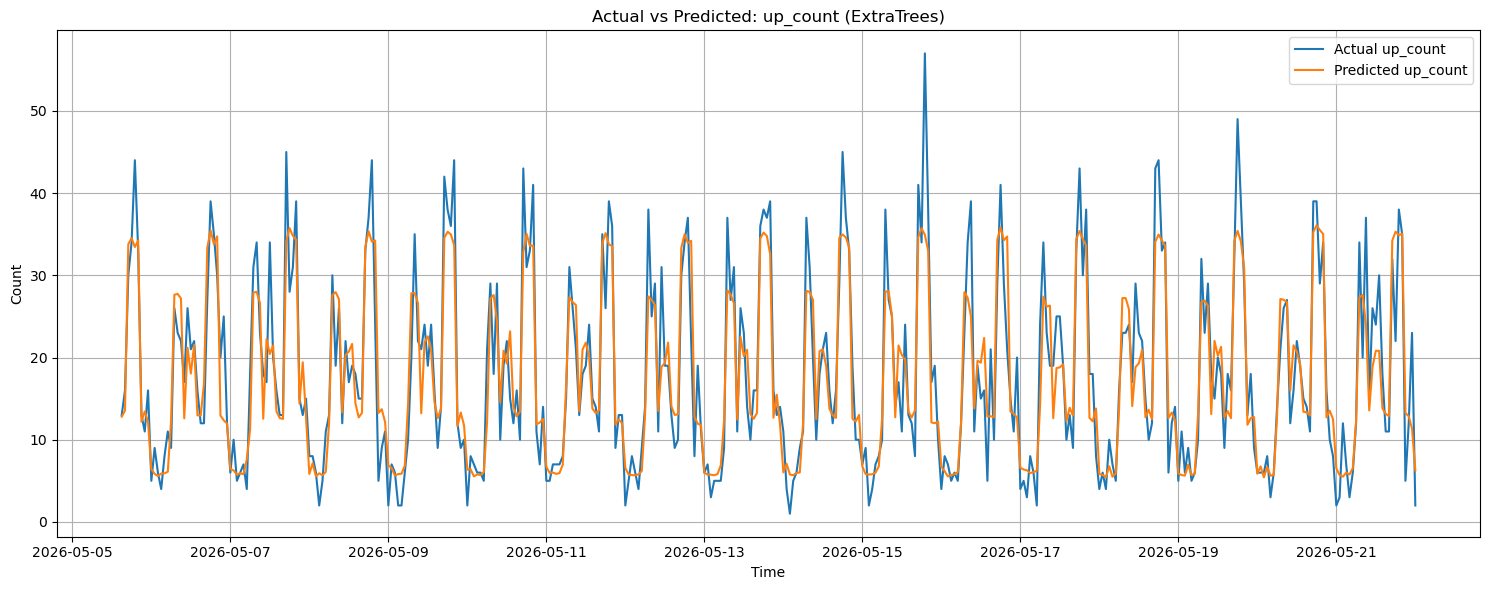

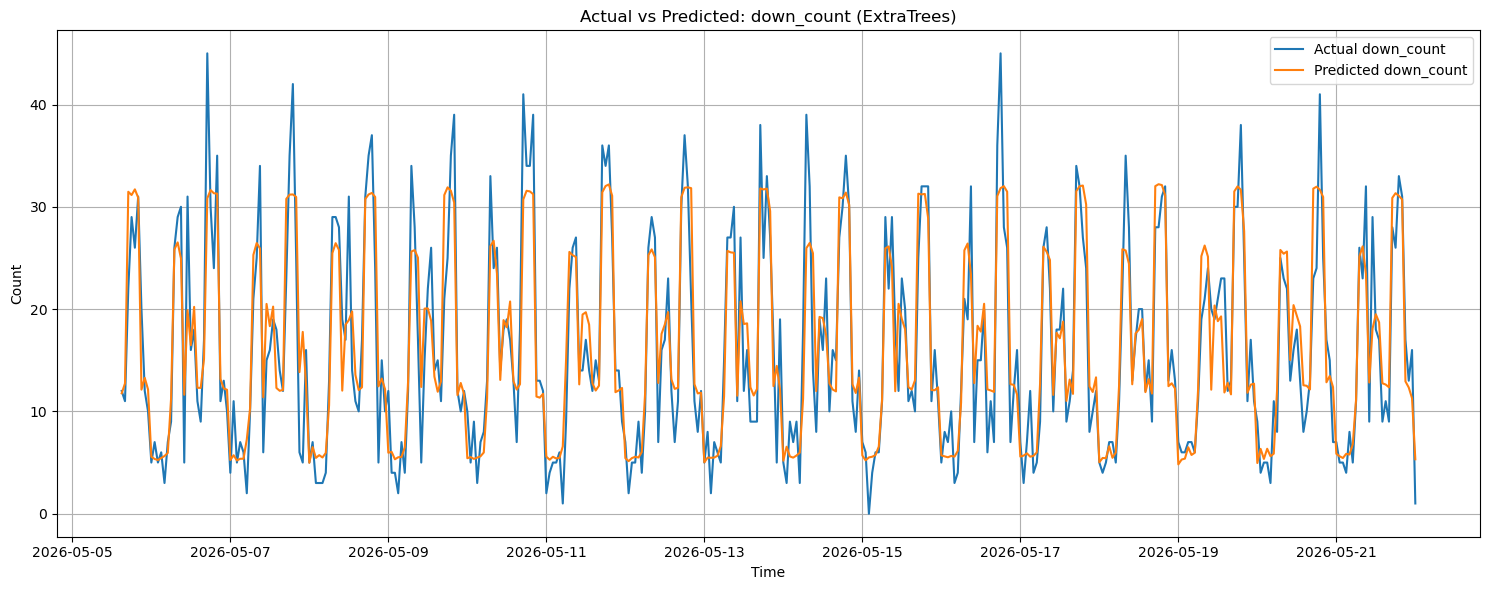

In [45]:
best_pred, _ = fit_predict_separate_targets(model_candidates[best_ml_name], X_train, y_train, X_test)
best_pred_df = pd.DataFrame(best_pred, columns=[f"pred_{c}" for c in TARGET_COLS], index=test_df.index)

plot_df = pd.concat([
    test_df[["time_hour"] + TARGET_COLS].reset_index(drop=True),
    best_pred_df.reset_index(drop=True)
], axis=1)

for target in TARGET_COLS:
    plt.figure(figsize=(15, 6))
    plt.plot(plot_df["time_hour"], plot_df[target], label=f"Actual {target}")
    plt.plot(plot_df["time_hour"], plot_df[f"pred_{target}"], label=f"Predicted {target}")
    plt.title(f"Actual vs Predicted: {target} ({best_ml_name})")
    plt.xlabel("Time")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

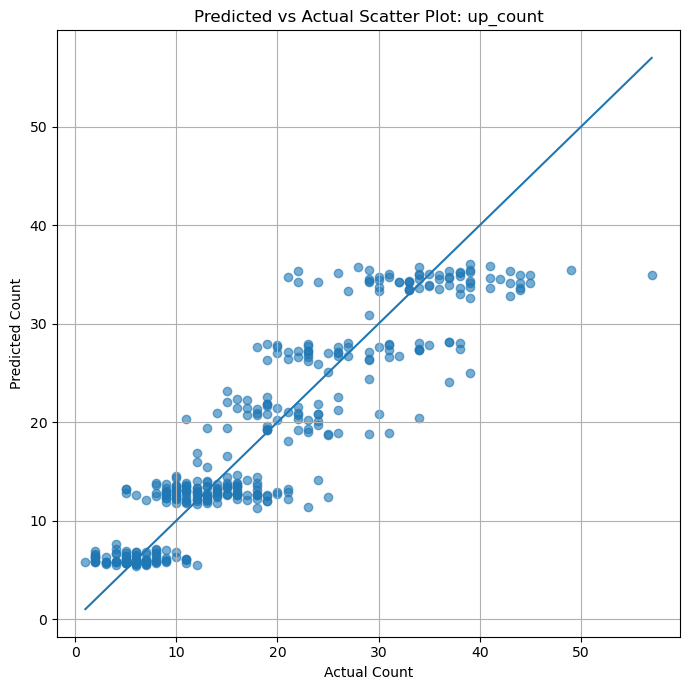

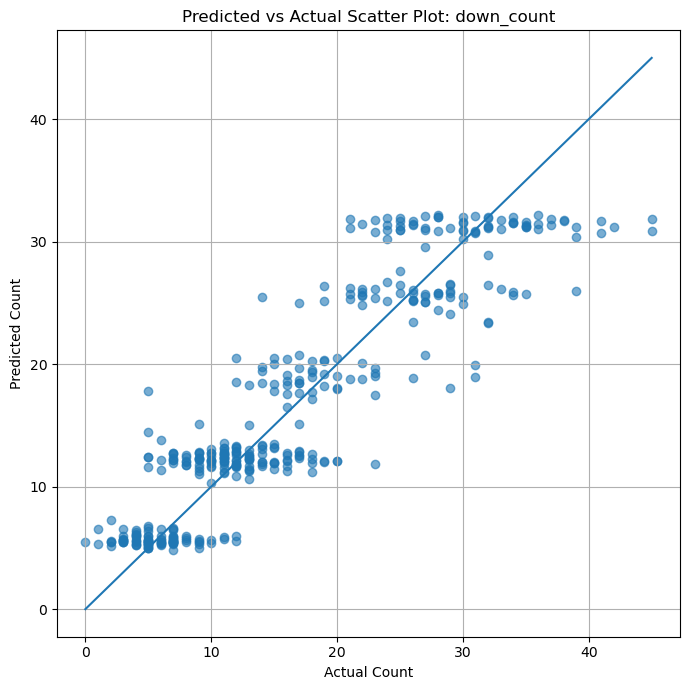

In [46]:
for target in TARGET_COLS:
    plt.figure(figsize=(7, 7))
    plt.scatter(plot_df[target], plot_df[f"pred_{target}"], alpha=0.6)

    min_value = min(plot_df[target].min(), plot_df[f"pred_{target}"].min())
    max_value = max(plot_df[target].max(), plot_df[f"pred_{target}"].max())
    plt.plot([min_value, max_value], [min_value, max_value])

    plt.title(f"Predicted vs Actual Scatter Plot: {target}")
    plt.xlabel("Actual Count")
    plt.ylabel("Predicted Count")
    plt.tight_layout()
    plt.show()

# 24. Error Analysis by Hour

This checks whether the model performs worse during certain hours.

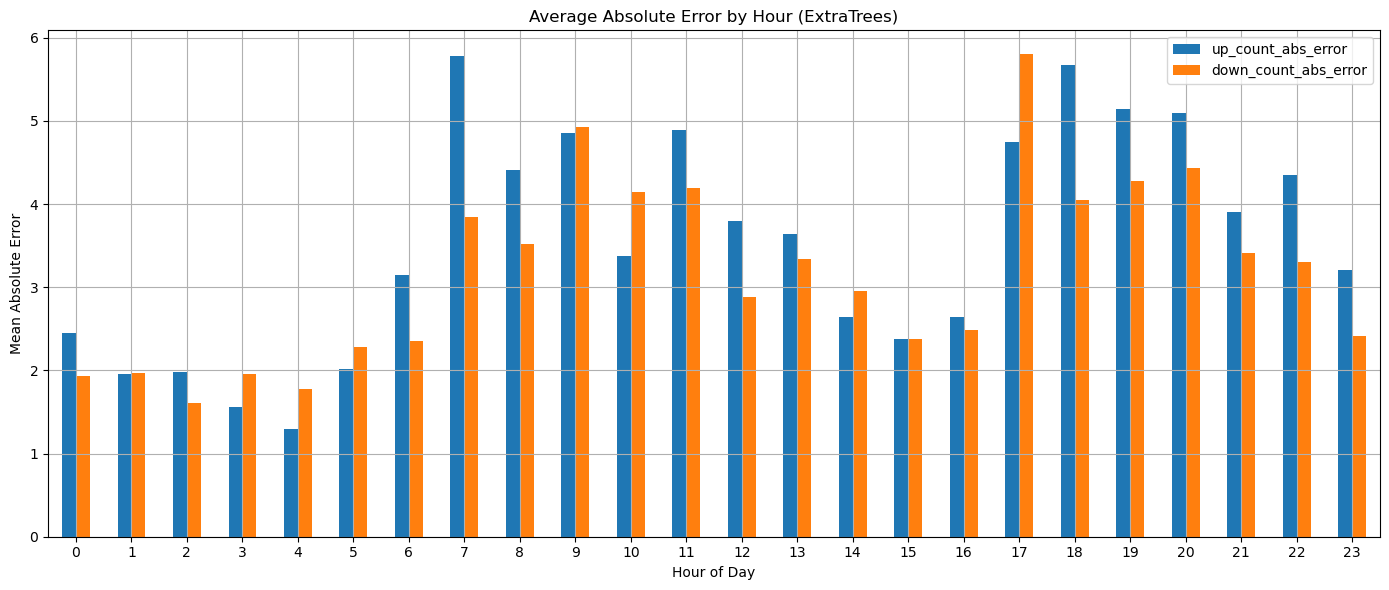

,up_count_abs_error,down_count_abs_error
hour,,
0,2.451500,1.937679
1,1.952155,1.965391
2,1.977965,1.604164
3,1.555318,1.959282
4,1.293607,1.775268
5,2.022092,2.285935
6,3.151996,2.351619
7,5.786848,3.840777
8,4.415548,3.515339


In [47]:
error_df = plot_df.copy()
error_df["hour"] = error_df["time_hour"].dt.hour

for target in TARGET_COLS:
    error_df[f"{target}_abs_error"] = np.abs(error_df[target] - error_df[f"pred_{target}"])

error_by_hour = error_df.groupby("hour")[[f"{target}_abs_error" for target in TARGET_COLS]].mean()

error_by_hour.plot(kind="bar", figsize=(14, 6))
plt.title(f"Average Absolute Error by Hour ({best_ml_name})")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

error_by_hour

# 25. Feature Importance

For tree-based models, we can inspect built-in feature importance.

For models without built-in importance, use permutation importance.

Feature importance for up_count


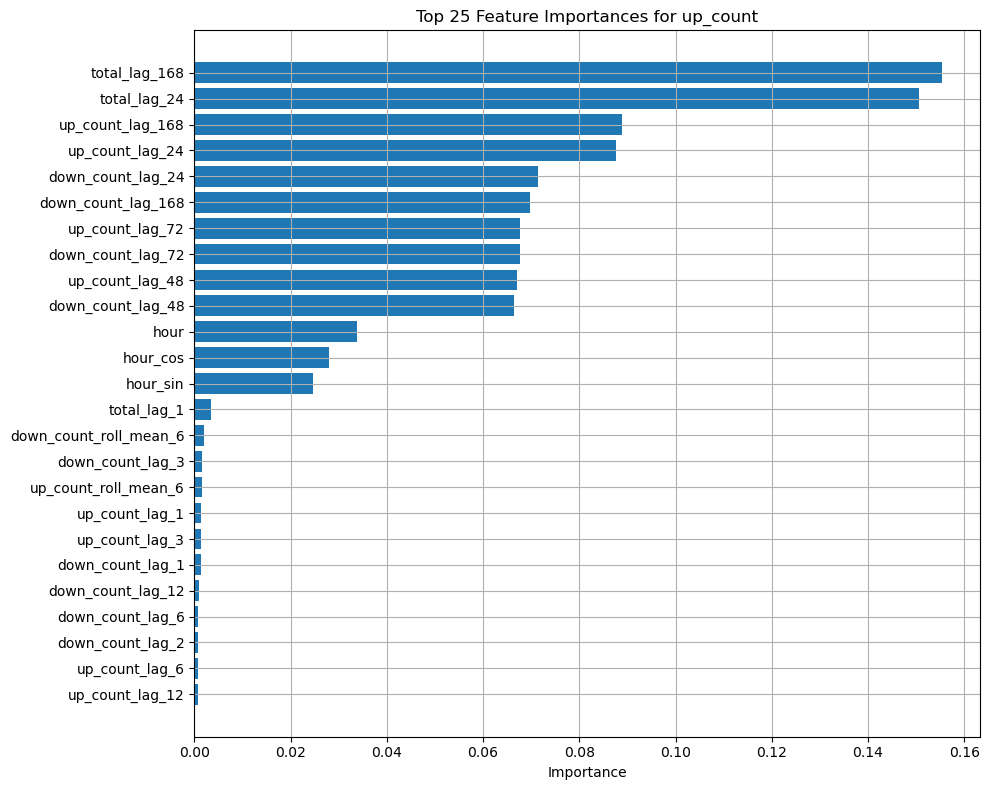

,feature,importance
43,total_lag_168,0.155403
42,total_lag_24,0.150561
19,up_count_lag_168,0.088810
16,up_count_lag_24,0.087706
31,down_count_lag_24,0.071434
34,down_count_lag_168,0.069657
18,up_count_lag_72,0.067775
33,down_count_lag_72,0.067601
17,up_count_lag_48,0.067012
32,down_count_lag_48,0.066365


Feature importance for down_count


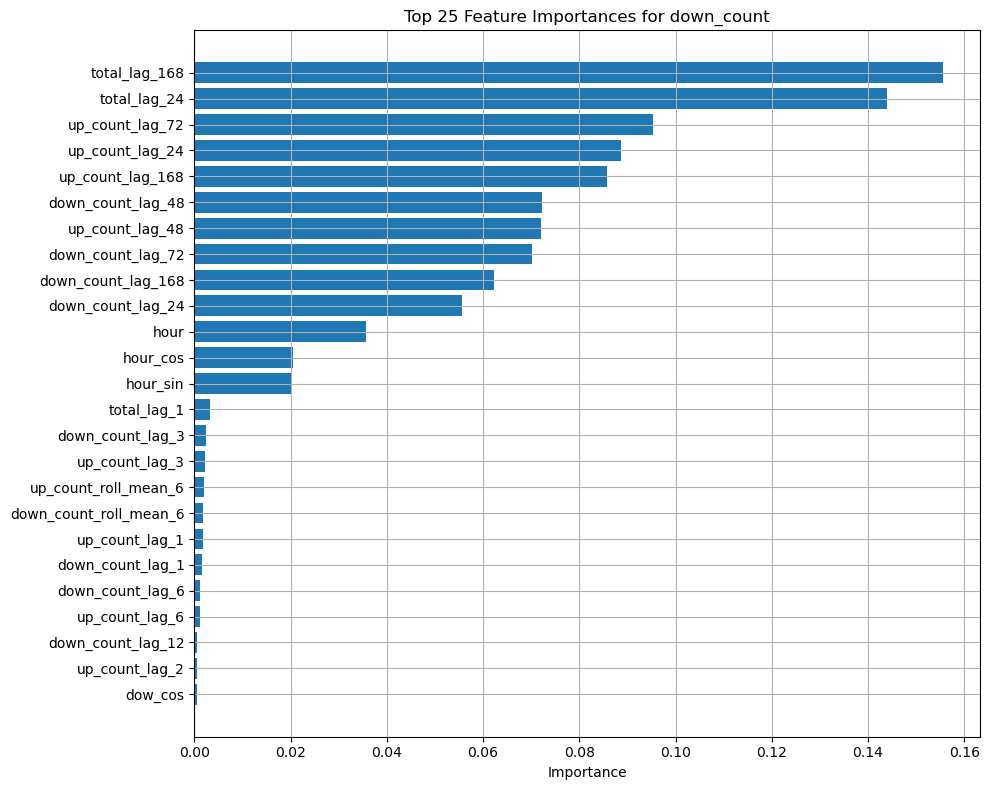

,feature,importance
43,total_lag_168,0.155496
42,total_lag_24,0.143981
18,up_count_lag_72,0.095348
16,up_count_lag_24,0.088582
19,up_count_lag_168,0.085658
32,down_count_lag_48,0.072280
17,up_count_lag_48,0.071958
33,down_count_lag_72,0.070159
34,down_count_lag_168,0.062338
31,down_count_lag_24,0.055591


In [48]:
def get_feature_importance(model, X_valid, y_valid, target_name, top_n=25):
    if hasattr(model, "feature_importances_"):
        importance = pd.DataFrame({
            "feature": X_valid.columns,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False)
    else:
        result = permutation_importance(
            model,
            X_valid,
            y_valid,
            n_repeats=5,
            random_state=RANDOM_STATE,
            scoring="neg_root_mean_squared_error"
        )
        importance = pd.DataFrame({
            "feature": X_valid.columns,
            "importance": result.importances_mean
        }).sort_values("importance", ascending=False)

    top_imp = importance.head(top_n)

    plt.figure(figsize=(10, 8))
    plt.barh(top_imp["feature"][::-1], top_imp["importance"][::-1])
    plt.title(f"Top {top_n} Feature Importances for {target_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return importance


best_fitted = fitted_model_store[best_ml_name]

importance_tables = {}

for target in TARGET_COLS:
    print(f"Feature importance for {target}")
    importance_tables[target] = get_feature_importance(
        best_fitted[target],
        X_test,
        y_test[target],
        target_name=target,
        top_n=25
    )
    display(importance_tables[target].head(20))

## Feature Importance Warning

If the top features contain forbidden same-hour columns such as:

- `up_count`
- `down_count`
- `total_count`

then the model is leaking.

The top features should usually be lag/rolling/time features such as:

- `up_count_lag_24`
- `down_count_lag_24`
- `up_count_lag_168`
- `hour_sin`
- `hour_cos`
- rolling mean features

# 26. Train Final Models on All Available Data

After evaluation is finished, the final models are trained on all available historical data before forecasting the next 3 days.

In [49]:
final_models = {}

for target in TARGET_COLS:
    from sklearn.base import clone
    model = clone(model_candidates[best_ml_name])
    model.fit(X, y[target])
    final_models[target] = model

# Store medians for fallback filling during recursive forecasting.
feature_medians = X.median(numeric_only=True)

print(f"Final models trained using: {best_ml_name}")
print("Training rows used:", len(X))

Final models trained using: ExtraTrees
Training rows used: 1969


# 27. Recursive Next 3 Days Forecast

To predict the next 3 days, the notebook predicts one hour at a time.

Process:

1. Predict next hour  
2. Add that prediction into the history  
3. Use it to create lag features for the following hour  
4. Repeat until 72 hours are predicted  

This is called **recursive forecasting**.

In [50]:
def build_next_feature_row(history_df, next_time, feature_cols, feature_medians):
    temp = pd.concat([
        history_df[["time_hour", "up_count", "down_count"]],
        pd.DataFrame({
            "time_hour": [next_time],
            "up_count": [np.nan],
            "down_count": [np.nan]
        })
    ], ignore_index=True)

    temp_features = make_lag_rolling_features(temp)
    next_row = temp_features.iloc[[-1]][feature_cols].copy()

    # Fill any missing values that might appear at the beginning.
    next_row = next_row.fillna(feature_medians)

    return next_row


def forecast_next_hours(history_df, final_models, feature_cols, horizon_hours=72):
    history = history_df[["time_hour", "up_count", "down_count"]].copy().sort_values("time_hour")
    forecast_rows = []

    for step in range(1, horizon_hours + 1):
        next_time = history["time_hour"].max() + pd.Timedelta(hours=1)
        X_next = build_next_feature_row(history, next_time, feature_cols, feature_medians)

        predictions = {}
        for target in TARGET_COLS:
            pred_value = final_models[target].predict(X_next)[0]
            pred_value = max(0, pred_value)
            predictions[target] = pred_value

        new_row = {
            "time_hour": next_time,
            "predicted_up_count": predictions["up_count"],
            "predicted_down_count": predictions["down_count"],
            "predicted_total_count": predictions["up_count"] + predictions["down_count"]
        }

        forecast_rows.append(new_row)

        # Append predictions as if they are actual future values for recursive lags.
        history = pd.concat([
            history,
            pd.DataFrame({
                "time_hour": [next_time],
                "up_count": [predictions["up_count"]],
                "down_count": [predictions["down_count"]]
            })
        ], ignore_index=True)

    forecast = pd.DataFrame(forecast_rows)

    forecast["date"] = forecast["time_hour"].dt.date
    forecast["hour"] = forecast["time_hour"].dt.hour
    forecast["day_name"] = forecast["time_hour"].dt.day_name()

    # Rounded counts are easier to read, but keep raw predictions too.
    forecast["predicted_up_count_rounded"] = forecast["predicted_up_count"].round().astype(int)
    forecast["predicted_down_count_rounded"] = forecast["predicted_down_count"].round().astype(int)
    forecast["predicted_total_count_rounded"] = forecast["predicted_total_count"].round().astype(int)

    return forecast


forecast_3_days = forecast_next_hours(
    history_df=hourly[["time_hour", "up_count", "down_count"]],
    final_models=final_models,
    feature_cols=feature_cols,
    horizon_hours=FORECAST_HOURS
)

forecast_3_days.head(20)

,time_hour,predicted_up_count,predicted_down_count,predicted_total_count,date,hour,day_name,predicted_up_count_rounded,predicted_down_count_rounded,predicted_total_count_rounded
0,2026-05-22 01:00:00,6.278092,5.813915,12.092008,2026-05-22,1,Friday,6,6,12
1,2026-05-22 02:00:00,6.612120,6.333321,12.945441,2026-05-22,2,Friday,7,6,13
2,2026-05-22 03:00:00,5.774271,5.765515,11.539786,2026-05-22,3,Friday,6,6,12
3,2026-05-22 04:00:00,5.573511,5.725357,11.298868,2026-05-22,4,Friday,6,6,11
4,2026-05-22 05:00:00,6.563273,6.030840,12.594113,2026-05-22,5,Friday,7,6,13
5,2026-05-22 06:00:00,11.878493,10.705028,22.583521,2026-05-22,6,Friday,12,11,23
6,2026-05-22 07:00:00,27.652158,25.804409,53.456568,2026-05-22,7,Friday,28,26,53
7,2026-05-22 08:00:00,26.871581,25.274085,52.145665,2026-05-22,8,Friday,27,25,52
8,2026-05-22 09:00:00,26.853109,25.790183,52.643293,2026-05-22,9,Friday,27,26,53
9,2026-05-22 10:00:00,14.954338,13.700955,28.655294,2026-05-22,10,Friday,15,14,29


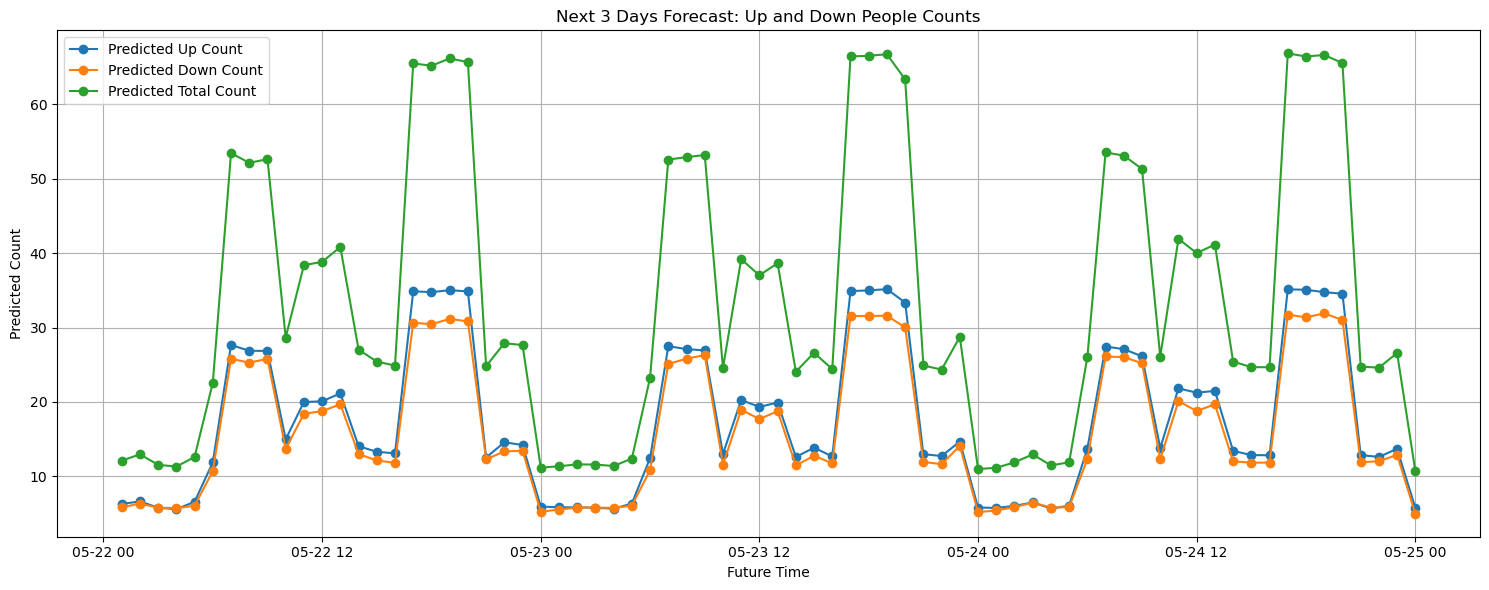

In [51]:
plt.figure(figsize=(15, 6))
plt.plot(forecast_3_days["time_hour"], forecast_3_days["predicted_up_count"], marker="o", label="Predicted Up Count")
plt.plot(forecast_3_days["time_hour"], forecast_3_days["predicted_down_count"], marker="o", label="Predicted Down Count")
plt.plot(forecast_3_days["time_hour"], forecast_3_days["predicted_total_count"], marker="o", label="Predicted Total Count")
plt.title("Next 3 Days Forecast: Up and Down People Counts")
plt.xlabel("Future Time")
plt.ylabel("Predicted Count")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
daily_forecast = (
    forecast_3_days
    .groupby("date")[["predicted_up_count", "predicted_down_count", "predicted_total_count"]]
    .sum()
    .round()
    .astype(int)
)

daily_forecast

,predicted_up_count,predicted_down_count,predicted_total_count
date,,,
2026-05-22,421,387,808
2026-05-23,420,387,807
2026-05-24,426,393,820
2026-05-25,6,5,11


# 28. Predict for a Specific Time of Day

Use this section when you want to answer questions like:

> How many people will go up or down at 8 AM for the next 3 days?

In [53]:
def get_forecast_for_specific_hour(forecast_df, hour):
    if not 0 <= hour <= 23:
        raise ValueError("hour must be between 0 and 23.")

    result = forecast_df[forecast_df["hour"] == hour].copy()

    columns_to_show = [
        "time_hour",
        "day_name",
        "predicted_up_count_rounded",
        "predicted_down_count_rounded",
        "predicted_total_count_rounded"
    ]

    return result[columns_to_show]


# Change this to any hour from 0 to 23.
SPECIFIC_HOUR = 8

specific_hour_forecast = get_forecast_for_specific_hour(forecast_3_days, SPECIFIC_HOUR)
specific_hour_forecast

,time_hour,day_name,predicted_up_count_rounded,predicted_down_count_rounded,predicted_total_count_rounded
7,2026-05-22 08:00:00,Friday,27,25,52
31,2026-05-23 08:00:00,Saturday,27,26,53
55,2026-05-24 08:00:00,Sunday,27,26,53


# 29. Save Forecast Results

In [54]:
forecast_output_path = "next_3_days_up_down_forecast.csv"
forecast_3_days.to_csv(forecast_output_path, index=False)

print(f"Forecast saved to: {forecast_output_path}")

Forecast saved to: next_3_days_up_down_forecast.csv


# 30. Final Conclusion

This notebook converted the original event-level traffic tracking dataset into an hourly forecasting dataset.

The original task was not a classification problem anymore. Instead, the model predicted two future count targets:

- `up_count`
- `down_count`

The strongest part of the workflow is that the modeling avoids same-hour target leakage. The model does not use current-hour `up_count`, `down_count`, or `total_count` as input features. Instead, it uses lagged and rolling historical features.

The final model is selected using time-based testing and compared against simple baselines. This is important because a forecasting model is only useful if it beats basic rules such as previous-hour or same-hour-yesterday predictions.

The notebook also creates a recursive 72-hour forecast, which represents the predicted up/down movement counts for the next 3 days.

## Final practical answer

To predict the next 3 days:

1. Train the model on historical hourly counts  
2. Create lag and rolling features from past data  
3. Predict the next hour  
4. Add that prediction back into the history  
5. Repeat the process for 72 hours  
6. Filter the forecast table by any specific hour of the day  

This gives a clear forecast of how many people are expected to move up or down at each future hour.

# 31. Submission Notes

For a strong report, mention these points:

- The dataset was transformed from event-level data into hourly count data.
- The target variables are `up_count` and `down_count`.
- The train/test split was time-based, not random.
- Same-hour target columns were excluded to prevent leakage.
- Heatmaps were used to identify hour/day movement patterns.
- Baseline models were used to judge whether ML models were actually useful.
- The final model was used recursively to forecast the next 72 hours.

Do not claim that the model is perfect just because R² is high.  
A very high R² must always be checked for leakage.